## Import

In [1]:
import gc, io, os, re, sys, time, warnings, random, h5py, kaolin
from contextlib import redirect_stderr
from typing import Dict, List, Optional
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.animation as animation
import pywt, optuna, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
import torch.optim as optim
from tqdm import tqdm
from typing import List
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator, rdMolDescriptors, rdPartialCharges, rdmolops
from rdkit.Chem.Draw import rdMolDraw2D
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.stats import skew, kurtosis, boxcox, ks_2samp
from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, RationalQuadratic, WhiteKernel
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams.update({
    "figure.dpi": 200, "font.family": "serif", "font.size": 12,
    "axes.labelsize": 14, "axes.titlesize": 13, "xtick.labelsize": 11,
    "ytick.labelsize": 11, "figure.titlesize": 16
})

SEED = 42
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
np.random.seed(SEED); random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
#import data 
df = pd.read_csv('./data/df_341.csv')
adhesion = df['Glass (kPa)_max'].values  

In [3]:
df

,Unnamed: 0,Nucleophilic-HEA,Hydrophobic-BA,Acidic-CBEA,Cationic-ATAC,Aromatic-PEA,Amide-AAm,Glass (kPa)_max
0,0,0.518703,0.199302,0.094768,0.187226,0.000000,0.000000,22.363765
1,1,0.421787,0.406214,0.171999,0.000000,0.000000,0.000000,12.569002
2,2,0.536864,0.108375,0.184067,0.170693,0.000000,0.000000,10.927105
3,3,0.216356,0.199474,0.088142,0.174303,0.321725,0.000000,126.822364
4,4,0.119821,0.410078,0.191813,0.187167,0.091121,0.000000,109.271054
...,...,...,...,...,...,...,...,...
336,336,0.009971,0.409814,0.020126,0.000000,0.399978,0.160111,62.222222
337,337,0.148399,0.366207,0.009875,0.079254,0.385828,0.010436,147.997169
338,338,0.000000,0.606319,0.000000,0.080813,0.312868,0.000000,229.752300
339,339,0.000000,0.666481,0.000000,0.080692,0.252826,0.000000,232.073602


## Data update

### Make FFP and 2D

In [4]:
monomers = {
    'HEA': 'C=CC(=O)OCCO',                            # 2-Hydroxyethyl acrylate
    'BA': 'C=CC(=O)OCCCC',                            # Butyl acrylate
    'CBEA': 'C=CC(=O)OCCC(=O)O',                      # Carboxyethyl acrylate
    'ATAC': 'C=CC(=O)OCC[N+](C)(C)C',                 # [2-(Acryloyloxy)ethyl]trimethylammonium
    'PEA': 'C=CC(=O)OCCOc1ccccc1',                    # 2-Phenoxyethyl acrylate
    'AAm': 'C=CC(=O)N'                                # Acrylamide
}
mon_names = list(monomers.keys())
mon_smiles = list(monomers.values())
mon_mols = [Chem.MolFromSmiles(s) for s in mon_smiles]
mon_cols = ['Nucleophilic-HEA', 'Hydrophobic-BA', 'Acidic-CBEA', 
            'Cationic-ATAC', 'Aromatic-PEA', 'Amide-AAm']

In [5]:
def custom_2d_autocorr_for_metrics(mol, lags=8):
    if mol is None or mol.GetNumAtoms() < 2:
        return np.zeros(3 * lags, dtype=np.float32)
    mol_calc = Chem.Mol(mol)
    rdPartialCharges.ComputeGasteigerCharges(mol_calc)
    dm = rdmolops.GetDistanceMatrix(mol_calc)
    contribs = rdMolDescriptors._CalcCrippenContribs(mol_calc)
    logp_arr = np.array([c[0] for c in contribs], dtype=np.float32)
    charge_arr = np.array([float(a.GetProp('_GasteigerCharge')) if a.HasProp('_GasteigerCharge') else 0.0 for a in mol_calc.GetAtoms()], dtype=np.float32)
    arom_arr = np.array([1.0 if atom.GetIsAromatic() or atom.GetHybridization() == Chem.HybridizationType.SP2 else 0.0 for atom in mol_calc.GetAtoms()], dtype=np.float32)
    prop_arrays = [logp_arr, charge_arr, arom_arr]
    autocorr_vec = []
    for prop_arr in prop_arrays:
        for lag in range(1, lags + 1):
            mask = (dm == lag)
            upper_mask = np.triu(mask, k=1)
            i_idx, j_idx = np.where(upper_mask)
            if len(i_idx) == 0:
                autocorr_vec.append(0.0)
            else:
                autocorr_vec.append(np.sum(prop_arr[i_idx] * prop_arr[j_idx]) / len(i_idx))
    return np.array(autocorr_vec, dtype=np.float32)

sizes = [2048, 16384, 1024, 512, 256, 128]
fps_data = []
for s in sizes:
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=s, atomInvariantsGenerator=rdFingerprintGenerator.GetMorganFeatureAtomInvGen())
    bin_arr = np.array([list(gen.GetFingerprint(mol)) for mol in mon_mols], dtype=np.int8)
    cnt_arr = np.array([gen.GetCountFingerprintAsNumPy(mol) for mol in mon_mols], dtype=np.uint16)
    fps_data.append((bin_arr, cnt_arr))
(ffp_arrays, cffp_arrays), (ffp_array, cffp_array), (ffp_arrays1, cffp_arrays1), (ffp_arrays2, cffp_arrays2), (ffp_arrays3, cffp_arrays3), (ffp_arrays4, cffp_arrays4) = fps_data

custom_feats = [custom_2d_autocorr_for_metrics(mol, lags=8) for mol in mon_mols]
rdkit_feats = [rdMolDescriptors.CalcAUTOCORR2D(mol) for mol in mon_mols]
merged = [np.concatenate([c, r]) for c, r in zip(custom_feats, rdkit_feats)]
autocorr_2d_arrays = np.array(merged, dtype=np.float32)


val_df = pd.DataFrame({
    'autocorr': list(autocorr_2d_arrays),
    'cffp_256': list(cffp_arrays3),
}, index=list(monomers.keys()))

In [6]:
val_df

,autocorr,cffp_256
HEA,"[0.022371456, 0.008917488, 0.0069393865, 0.012...","[5, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
BA,"[0.008565082, -0.0035981897, -0.016295668, -0....","[7, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
CBEA,"[0.012207642, 0.0016877461, 0.004259186, 0.012...","[5, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
ATAC,"[0.037416205, 0.024702458, 0.01881262, 0.01488...","[8, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
PEA,"[0.016208153, 0.0073456024, -0.008653098, -0.0...","[5, 0, 3, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
AAm,"[0.07673699, -0.017345022, -0.09085759, 0.0, 0...","[3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [7]:

col_to_mon = {'Nucleophilic-HEA': 'HEA', 'Hydrophobic-BA': 'BA', 'Acidic-CBEA': 'CBEA', 'Cationic-ATAC': 'ATAC', 'Aromatic-PEA': 'PEA', 'Amide-AAm': 'AAm'}
name_to_idx = {name: i for i, name in enumerate(val_df.index)}
mon_indices = np.array([name_to_idx[col_to_mon[col]] for col in mon_cols], dtype=np.int32)
features_source = {
    'autocorr': (autocorr_2d_arrays, np.float32),
    'cffp_256': (cffp_arrays3, np.uint16)
}

In [8]:
comp = df[mon_cols].values.astype(np.float64)
row_sums = comp.sum(axis=1, keepdims=True)
comp = np.where(row_sums > 1.5, comp / 100.0, comp)
row_sums = comp.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
comp /= row_sums

col_to_mon = {'Nucleophilic-HEA': 'HEA', 'Hydrophobic-BA': 'BA', 'Acidic-CBEA': 'CBEA', 'Cationic-ATAC': 'ATAC', 'Aromatic-PEA': 'PEA', 'Amide-AAm': 'AAm'}
name_to_idx = {name: i for i, name in enumerate(val_df.index)}
mon_indices = np.array([name_to_idx[col_to_mon[col]] for col in mon_cols], dtype=np.int32)

features_source = {
    'autocorr': (autocorr_2d_arrays, np.float32),
    'cffp_256': (cffp_arrays3, np.uint16)
}

valid_mask = comp.sum(axis=1) > 0
valid_comps = comp[valid_mask]
n_poly_valid = int(valid_mask.sum())

np.random.seed(42)
N_mon, batch_size = 1000, 256

def flush_batch(datasets, buffers, count, size):
    for name in datasets:
        datasets[name][count:count+size] = buffers[name][:size]

with h5py.File('./data/DL/small_poly_datasets.h5', 'w') as f:
    hdf_datasets, buffers = {}, {}
    for name, (src, dtype) in features_source.items():
        shape_3d = (n_poly_valid, N_mon, src.shape[1])
        chunk_shape = (min(batch_size, n_poly_valid), N_mon, src.shape[1])
        hdf_datasets[name] = f.create_dataset(
            name, shape=shape_3d, dtype=dtype,
            compression="gzip", compression_opts=4,
            chunks=chunk_shape, shuffle=True
        )
        buffers[name] = np.empty((batch_size, N_mon, src.shape[1]), dtype=dtype)

    buf_idx = saved_count = 0
    for fracs in valid_comps:
        exact = fracs * N_mon
        counts = np.floor(exact).astype(np.int32)
        diff = N_mon - counts.sum()
        if diff > 0:
            rem_indices = np.argsort(exact % 1)[::-1]
            counts[rem_indices[:diff]] += 1
        global_chain = np.repeat(mon_indices, counts)
        np.random.shuffle(global_chain)
        for name, (src, _) in features_source.items():
            buffers[name][buf_idx] = src[global_chain]
        buf_idx += 1
        if buf_idx == batch_size:
            flush_batch(hdf_datasets, buffers, saved_count, batch_size)
            saved_count += batch_size
            buf_idx = 0
            sys.stdout.write(f"typed:{saved_count}/{n_poly_valid}...\r")
            sys.stdout.flush()
    if buf_idx > 0:
        flush_batch(hdf_datasets, buffers, saved_count, buf_idx)
        saved_count += buf_idx
        sys.stdout.write(f"typed: {saved_count}/{n_poly_valid}...\r")
        sys.stdout.flush()

print(f"\n N:{n_poly_valid} in 'small_poly_datasets.h5'!")

typed: 341/341...
 N:341 in 'small_poly_datasets.h5'!


In [9]:
with h5py.File('./data/DL/small_poly_datasets.h5', 'r') as f:
    print(f"{'Name':<20} | {'Shape':<20} | {'Type':<10}")
    print("-" * 60)
    for key in f:
        obj = f[key]
        print(f"{key:<20} | {str(obj.shape):<20} | {str(obj.dtype):<10}" if isinstance(obj, h5py.Dataset) else f"{key:<20}")

Name                 | Shape                | Type      
------------------------------------------------------------
autocorr             | (341, 1000, 216)     | float32   
cffp_256             | (341, 1000, 256)     | uint16    


### New_poly_base

In [10]:
dfb = pd.read_csv('./data/poly_base.csv', sep=',')

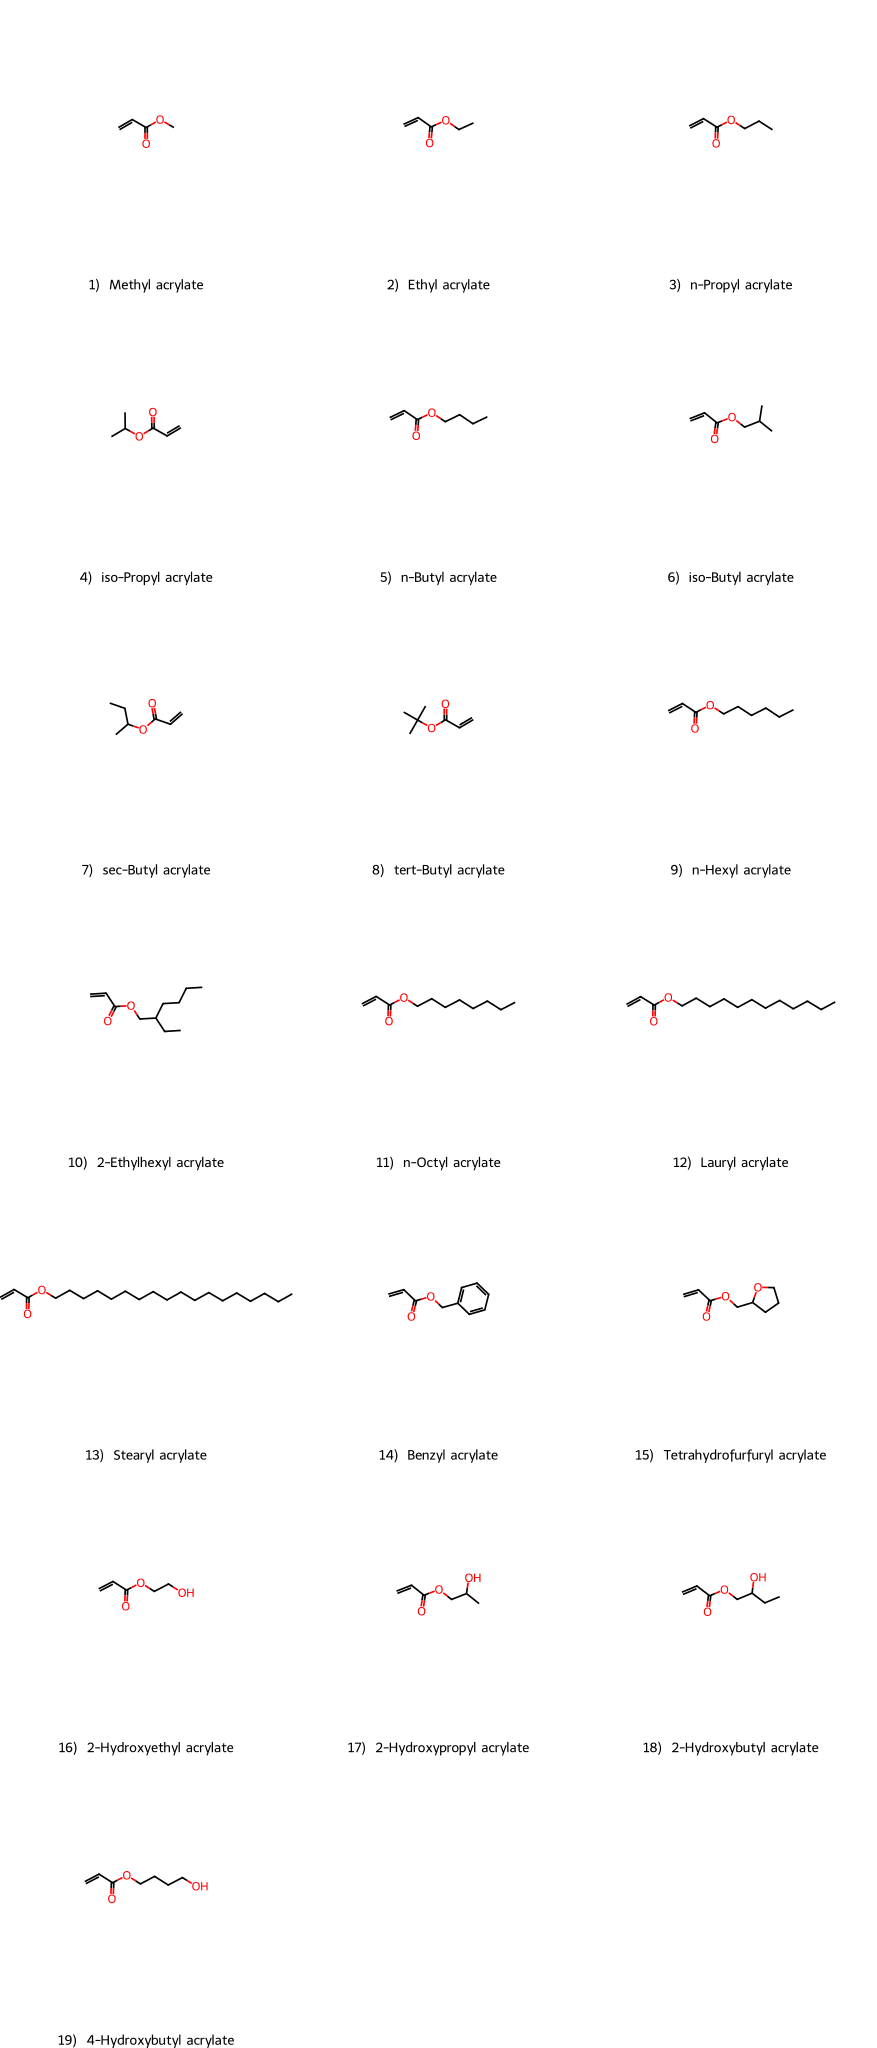

In [11]:
mols = [Chem.MolFromSmiles(s) for s in dfb['smiles']][:19]
leg = [f"{r['number']})  {r['name']}"for _, r in dfb.iterrows()][:19]
d=rdMolDraw2D.MolDrawOptions()
d.bondLineWidth=2
d.minFontSize=14
d.padding=0.0
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(350, 350), legends=leg, useSVG = True, drawOptions=d)

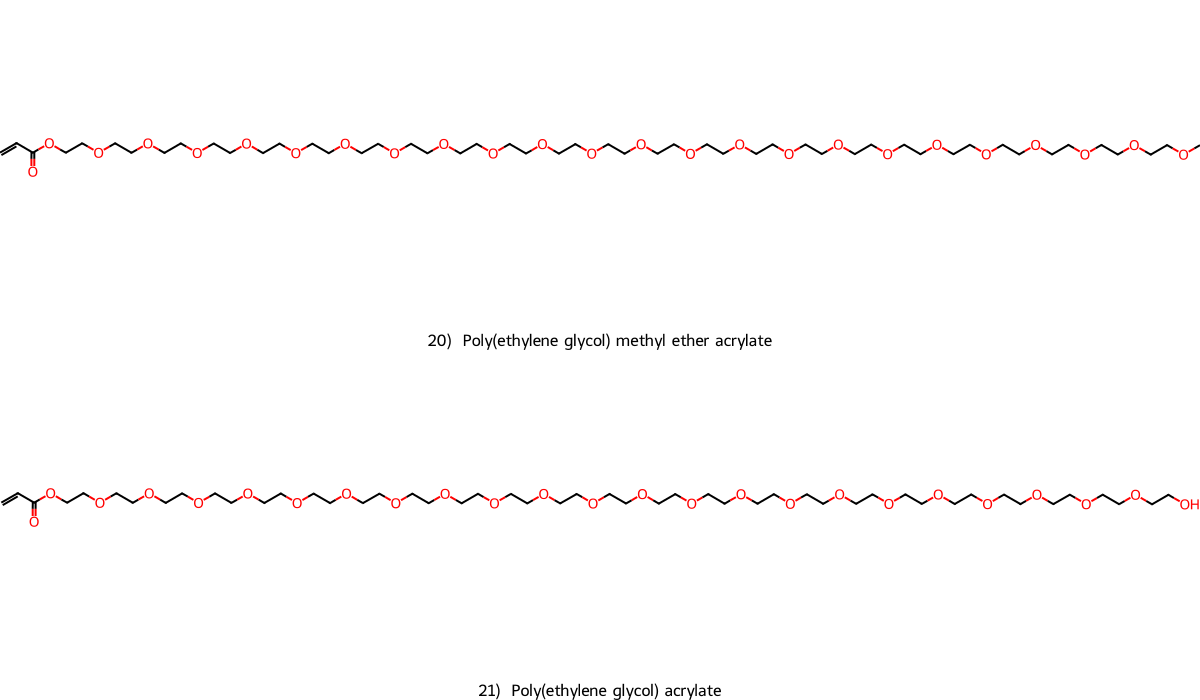

In [12]:
mols = [Chem.MolFromSmiles(s) for s in dfb['smiles']][:21][19:]
leg = [f"{r['number']})  {r['name']}"for _, r in dfb.iterrows()][:21][19:]
d=rdMolDraw2D.MolDrawOptions()
d.bondLineWidth=2
d.minFontSize=14
d.padding=0.0
Draw.MolsToGridImage(mols, molsPerRow=1, subImgSize=(1200, 350), legends=leg, useSVG = True, drawOptions=d)

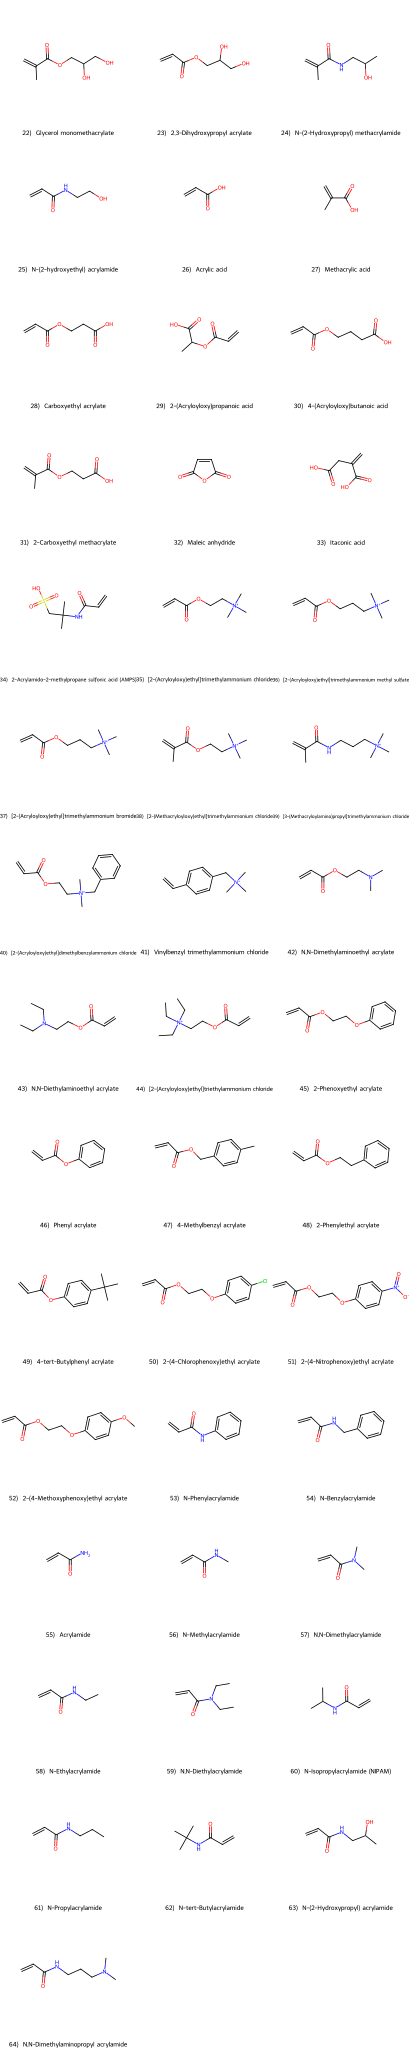

In [13]:
mols = [Chem.MolFromSmiles(s) for s in dfb['smiles']][21:]
leg = [f"{r['number']})  {r['name']}"for _, r in dfb.iterrows()][21:]
d=rdMolDraw2D.MolDrawOptions()
d.bondLineWidth=2
d.minFontSize=14
d.padding=0.0
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(350, 350), legends=leg, useSVG = True, drawOptions=d)

In [14]:
dfb

,number,name,family,smiles
0,1,Methyl acrylate,Alkyl Acrylates,C=CC(=O)OC
1,2,Ethyl acrylate,Alkyl Acrylates,C=CC(=O)OCC
2,3,n-Propyl acrylate,Alkyl Acrylates,C=CC(=O)OCCC
3,4,iso-Propyl acrylate,Alkyl Acrylates,C=CC(=O)OC(C)C
4,5,n-Butyl acrylate,Alkyl Acrylates,C=CC(=O)OCCCC
...,...,...,...,...
59,60,N-Isopropylacrylamide (NIPAM),Acrylamides,C=CC(=O)NC(C)C
60,61,N-Propylacrylamide,Acrylamides,C=CC(=O)NCCC
61,62,N-tert-Butylacrylamide,Acrylamides,C=CC(=O)NC(C)(C)C
62,63,N-(2-Hydroxypropyl) acrylamide,Acrylamides,C=CC(=O)NCC(C)O


In [15]:
smiles_list = dfb['smiles']

In [16]:
mon_mols = []
valid_indices = []
for i, smi in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mon_mols.append(mol)
        valid_indices.append(i)
    else:
        print(f"Warning: invalid SMILES at row {i}: {smi}")

custom_feats = [custom_2d_autocorr_for_metrics(mol) for mol in mon_mols]
rdkit_feats = [rdMolDescriptors.CalcAUTOCORR2D(mol) for mol in mon_mols]
autocorr_2d_arrays = np.array([np.concatenate([c, r]) for c, r in zip(custom_feats, rdkit_feats)], dtype=np.float32)

def _gen_fps(size):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=size, atomInvariantsGenerator=rdFingerprintGenerator.GetMorganFeatureAtomInvGen())
    return (np.array([list(gen.GetFingerprint(mol)) for mol in mon_mols], dtype=np.int8),
            np.array([gen.GetCountFingerprintAsNumPy(mol) for mol in mon_mols], dtype=np.uint16))

(ffp_arrays3, cffp_arrays3) = _gen_fps(256)

valid_df = dfb.iloc[valid_indices].reset_index(drop=True)
valid_df['autocorr'] = list(autocorr_2d_arrays)
valid_df['cffp_256'] = list(cffp_arrays3)

In [17]:
valid_df

,number,name,family,smiles,autocorr,cffp_256
0,1,Methyl acrylate,Alkyl Acrylates,C=CC(=O)OC,"[0.011263078, -0.0020739068, -0.008696463, -0....","[4, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2,Ethyl acrylate,Alkyl Acrylates,C=CC(=O)OCC,"[0.0044985064, -0.0033709956, -0.0149777755, -...","[5, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,3,n-Propyl acrylate,Alkyl Acrylates,C=CC(=O)OCCC,"[0.0068222643, -0.007078618, -0.014124219, -0....","[6, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,4,iso-Propyl acrylate,Alkyl Acrylates,C=CC(=O)OC(C)C,"[-0.00038357027, -0.0011090415, -0.019165983, ...","[6, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,5,n-Butyl acrylate,Alkyl Acrylates,C=CC(=O)OCCCC,"[0.008565082, -0.0035981897, -0.016295668, -0....","[7, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...
59,60,N-Isopropylacrylamide (NIPAM),Acrylamides,C=CC(=O)NC(C)C,"[0.043895867, -0.024408646, -0.035741005, -0.0...","[6, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
60,61,N-Propylacrylamide,Acrylamides,C=CC(=O)NCCC,"[0.05095514, -0.020507175, -0.046098724, -0.01...","[6, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
61,62,N-tert-Butylacrylamide,Acrylamides,C=CC(=O)NC(C)(C)C,"[0.03471452, -0.023272084, -0.03636415, -0.004...","[7, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
62,63,N-(2-Hydroxypropyl) acrylamide,Acrylamides,C=CC(=O)NCC(C)O,"[0.054595485, 0.013491831, 0.0036967525, 0.001...","[6, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."


In [18]:
valid_df.to_csv('./data/DL/monomers_with_descriptors.csv', index=False)

### Make_New_data_for_Random_poly

In [19]:
ffp_list = valid_df['cffp_256'].tolist()
auto_list = valid_df['autocorr'].tolist()
num_monomers = len(ffp_list)
ffp_len, auto_len = len(ffp_list[0]), len(auto_list[0])
TOTAL_SAMPLES, BATCH_SIZE, SEQ_LEN = 100000, 5000, 1000

with h5py.File('./data/DL/Deep_poly_datasets_Tr.h5', 'w') as f:
    dset_ffp = f.create_dataset('cffp_256', shape=(0, SEQ_LEN, ffp_len), maxshape=(None, SEQ_LEN, ffp_len), dtype=np.float32, compression='gzip', compression_opts=4)
    dset_auto = f.create_dataset('autocorr', shape=(0, SEQ_LEN, auto_len), maxshape=(None, SEQ_LEN, auto_len), dtype=np.float32, compression='gzip', compression_opts=4)

    for start in range(0, TOTAL_SAMPLES, BATCH_SIZE):
        end = min(start + BATCH_SIZE, TOTAL_SAMPLES)
        batch_size = end - start
        ffp_chunk = np.empty((batch_size, SEQ_LEN, ffp_len), dtype=np.float32)
        auto_chunk = np.empty((batch_size, SEQ_LEN, auto_len), dtype=np.float32)
        for i in range(batch_size):
            k = random.randint(1, 7)
            idxs = random.sample(range(num_monomers), k)
            r = np.random.dirichlet(np.ones(k))
            picks = np.random.choice(idxs, size=SEQ_LEN, p=r)
            ffp_chunk[i] = [ffp_list[j] for j in picks]
            auto_chunk[i] = [auto_list[j] for j in picks]
        dset_ffp.resize(dset_ffp.shape[0] + batch_size, axis=0)
        dset_auto.resize(dset_auto.shape[0] + batch_size, axis=0)
        dset_ffp[-batch_size:] = ffp_chunk
        dset_auto[-batch_size:] = auto_chunk
        print(f"Gen: {end} from {TOTAL_SAMPLES}")
print("Deep_poly_datasets_Tr.h5")

Gen: 5000 from 100000
Gen: 10000 from 100000
Gen: 15000 from 100000
Gen: 20000 from 100000
Gen: 25000 from 100000
Gen: 30000 from 100000
Gen: 35000 from 100000
Gen: 40000 from 100000
Gen: 45000 from 100000
Gen: 50000 from 100000
Gen: 55000 from 100000
Gen: 60000 from 100000
Gen: 65000 from 100000
Gen: 70000 from 100000
Gen: 75000 from 100000
Gen: 80000 from 100000
Gen: 85000 from 100000
Gen: 90000 from 100000
Gen: 95000 from 100000
Gen: 100000 from 100000
Deep_poly_datasets_Tr.h5


In [20]:
ffp_list = valid_df['cffp_256'].tolist()
auto_list = valid_df['autocorr'].tolist()
num_monomers = len(ffp_list)
ffp_len, auto_len = len(ffp_list[0]), len(auto_list[0])
TOTAL_SAMPLES, BATCH_SIZE, SEQ_LEN = 10000, 5000, 1000

with h5py.File('./data/DL/Deep_poly_datasets_Ts.h5', 'w') as f:
    dset_ffp = f.create_dataset('cffp_256', shape=(0, SEQ_LEN, ffp_len), maxshape=(None, SEQ_LEN, ffp_len), dtype=np.float32, compression='gzip', compression_opts=4)
    dset_auto = f.create_dataset('autocorr', shape=(0, SEQ_LEN, auto_len), maxshape=(None, SEQ_LEN, auto_len), dtype=np.float32, compression='gzip', compression_opts=4)

    for start in range(0, TOTAL_SAMPLES, BATCH_SIZE):
        end = min(start + BATCH_SIZE, TOTAL_SAMPLES)
        batch_size = end - start
        ffp_chunk = np.empty((batch_size, SEQ_LEN, ffp_len), dtype=np.float32)
        auto_chunk = np.empty((batch_size, SEQ_LEN, auto_len), dtype=np.float32)
        for i in range(batch_size):
            k = random.randint(1, 7)
            idxs = random.sample(range(num_monomers), k)
            r = np.random.dirichlet(np.ones(k))
            picks = np.random.choice(idxs, size=SEQ_LEN, p=r)
            ffp_chunk[i] = [ffp_list[j] for j in picks]
            auto_chunk[i] = [auto_list[j] for j in picks]
        dset_ffp.resize(dset_ffp.shape[0] + batch_size, axis=0)
        dset_auto.resize(dset_auto.shape[0] + batch_size, axis=0)
        dset_ffp[-batch_size:] = ffp_chunk
        dset_auto[-batch_size:] = auto_chunk
        print(f"Gen: {end} из {TOTAL_SAMPLES}")
print("Deep_poly_datasets_Ts.h5")

Gen: 5000 из 10000
Gen: 10000 из 10000
Deep_poly_datasets_Ts.h5


In [21]:
ffp_list = valid_df['cffp_256'].tolist()
auto_list = valid_df['autocorr'].tolist()
num_monomers = len(ffp_list)
ffp_len, auto_len = len(ffp_list[0]), len(auto_list[0])
TOTAL_SAMPLES, BATCH_SIZE, SEQ_LEN = 10000, 5000, 1000

with h5py.File('./data/DL/Deep_poly_datasets_Val.h5', 'w') as f:
    dset_ffp = f.create_dataset('cffp_256', shape=(0, SEQ_LEN, ffp_len), maxshape=(None, SEQ_LEN, ffp_len), dtype=np.float32, compression='gzip', compression_opts=4)
    dset_auto = f.create_dataset('autocorr', shape=(0, SEQ_LEN, auto_len), maxshape=(None, SEQ_LEN, auto_len), dtype=np.float32, compression='gzip', compression_opts=4)

    for start in range(0, TOTAL_SAMPLES, BATCH_SIZE):
        end = min(start + BATCH_SIZE, TOTAL_SAMPLES)
        batch_size = end - start
        ffp_chunk = np.empty((batch_size, SEQ_LEN, ffp_len), dtype=np.float32)
        auto_chunk = np.empty((batch_size, SEQ_LEN, auto_len), dtype=np.float32)
        for i in range(batch_size):
            k = random.randint(1, 7)
            idxs = random.sample(range(num_monomers), k)
            r = np.random.dirichlet(np.ones(k))
            picks = np.random.choice(idxs, size=SEQ_LEN, p=r)
            ffp_chunk[i] = [ffp_list[j] for j in picks]
            auto_chunk[i] = [auto_list[j] for j in picks]
        dset_ffp.resize(dset_ffp.shape[0] + batch_size, axis=0)
        dset_auto.resize(dset_auto.shape[0] + batch_size, axis=0)
        dset_ffp[-batch_size:] = ffp_chunk
        dset_auto[-batch_size:] = auto_chunk
        print(f"Gen: {end} из {TOTAL_SAMPLES}")
print("Deep_poly_datasets_Val.h5")

Gen: 5000 из 10000
Gen: 10000 из 10000
Deep_poly_datasets_Val.h5


## Data analyze 

In [22]:
#### Distribution

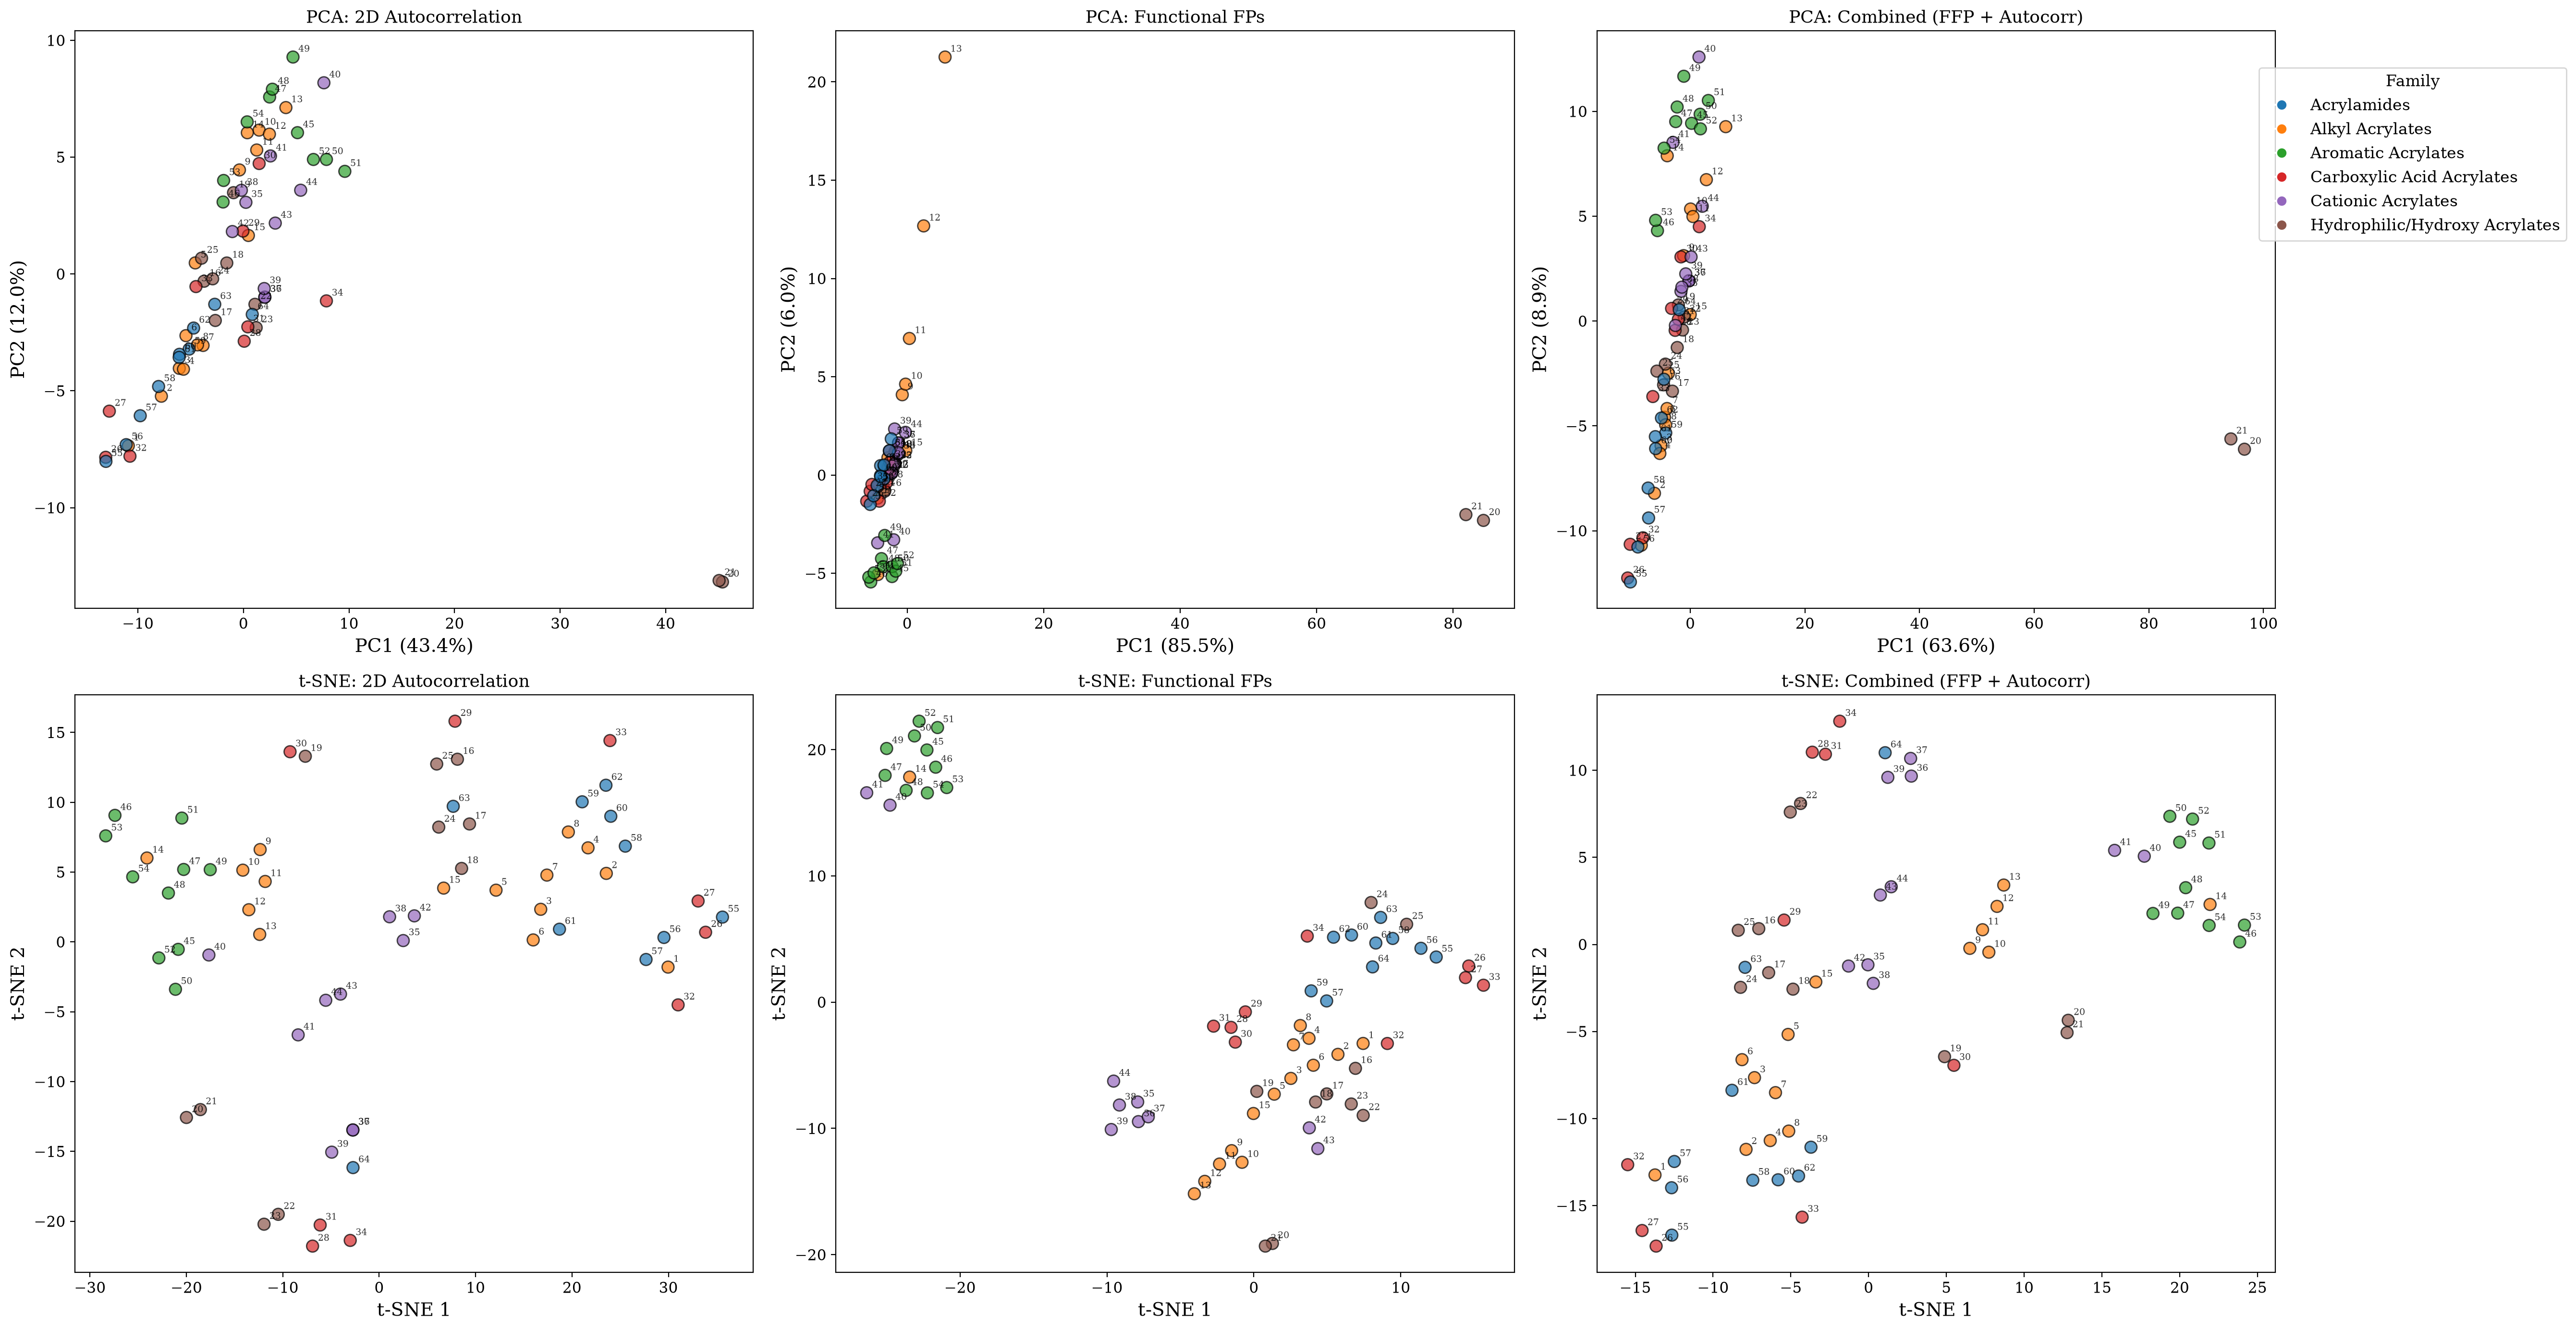

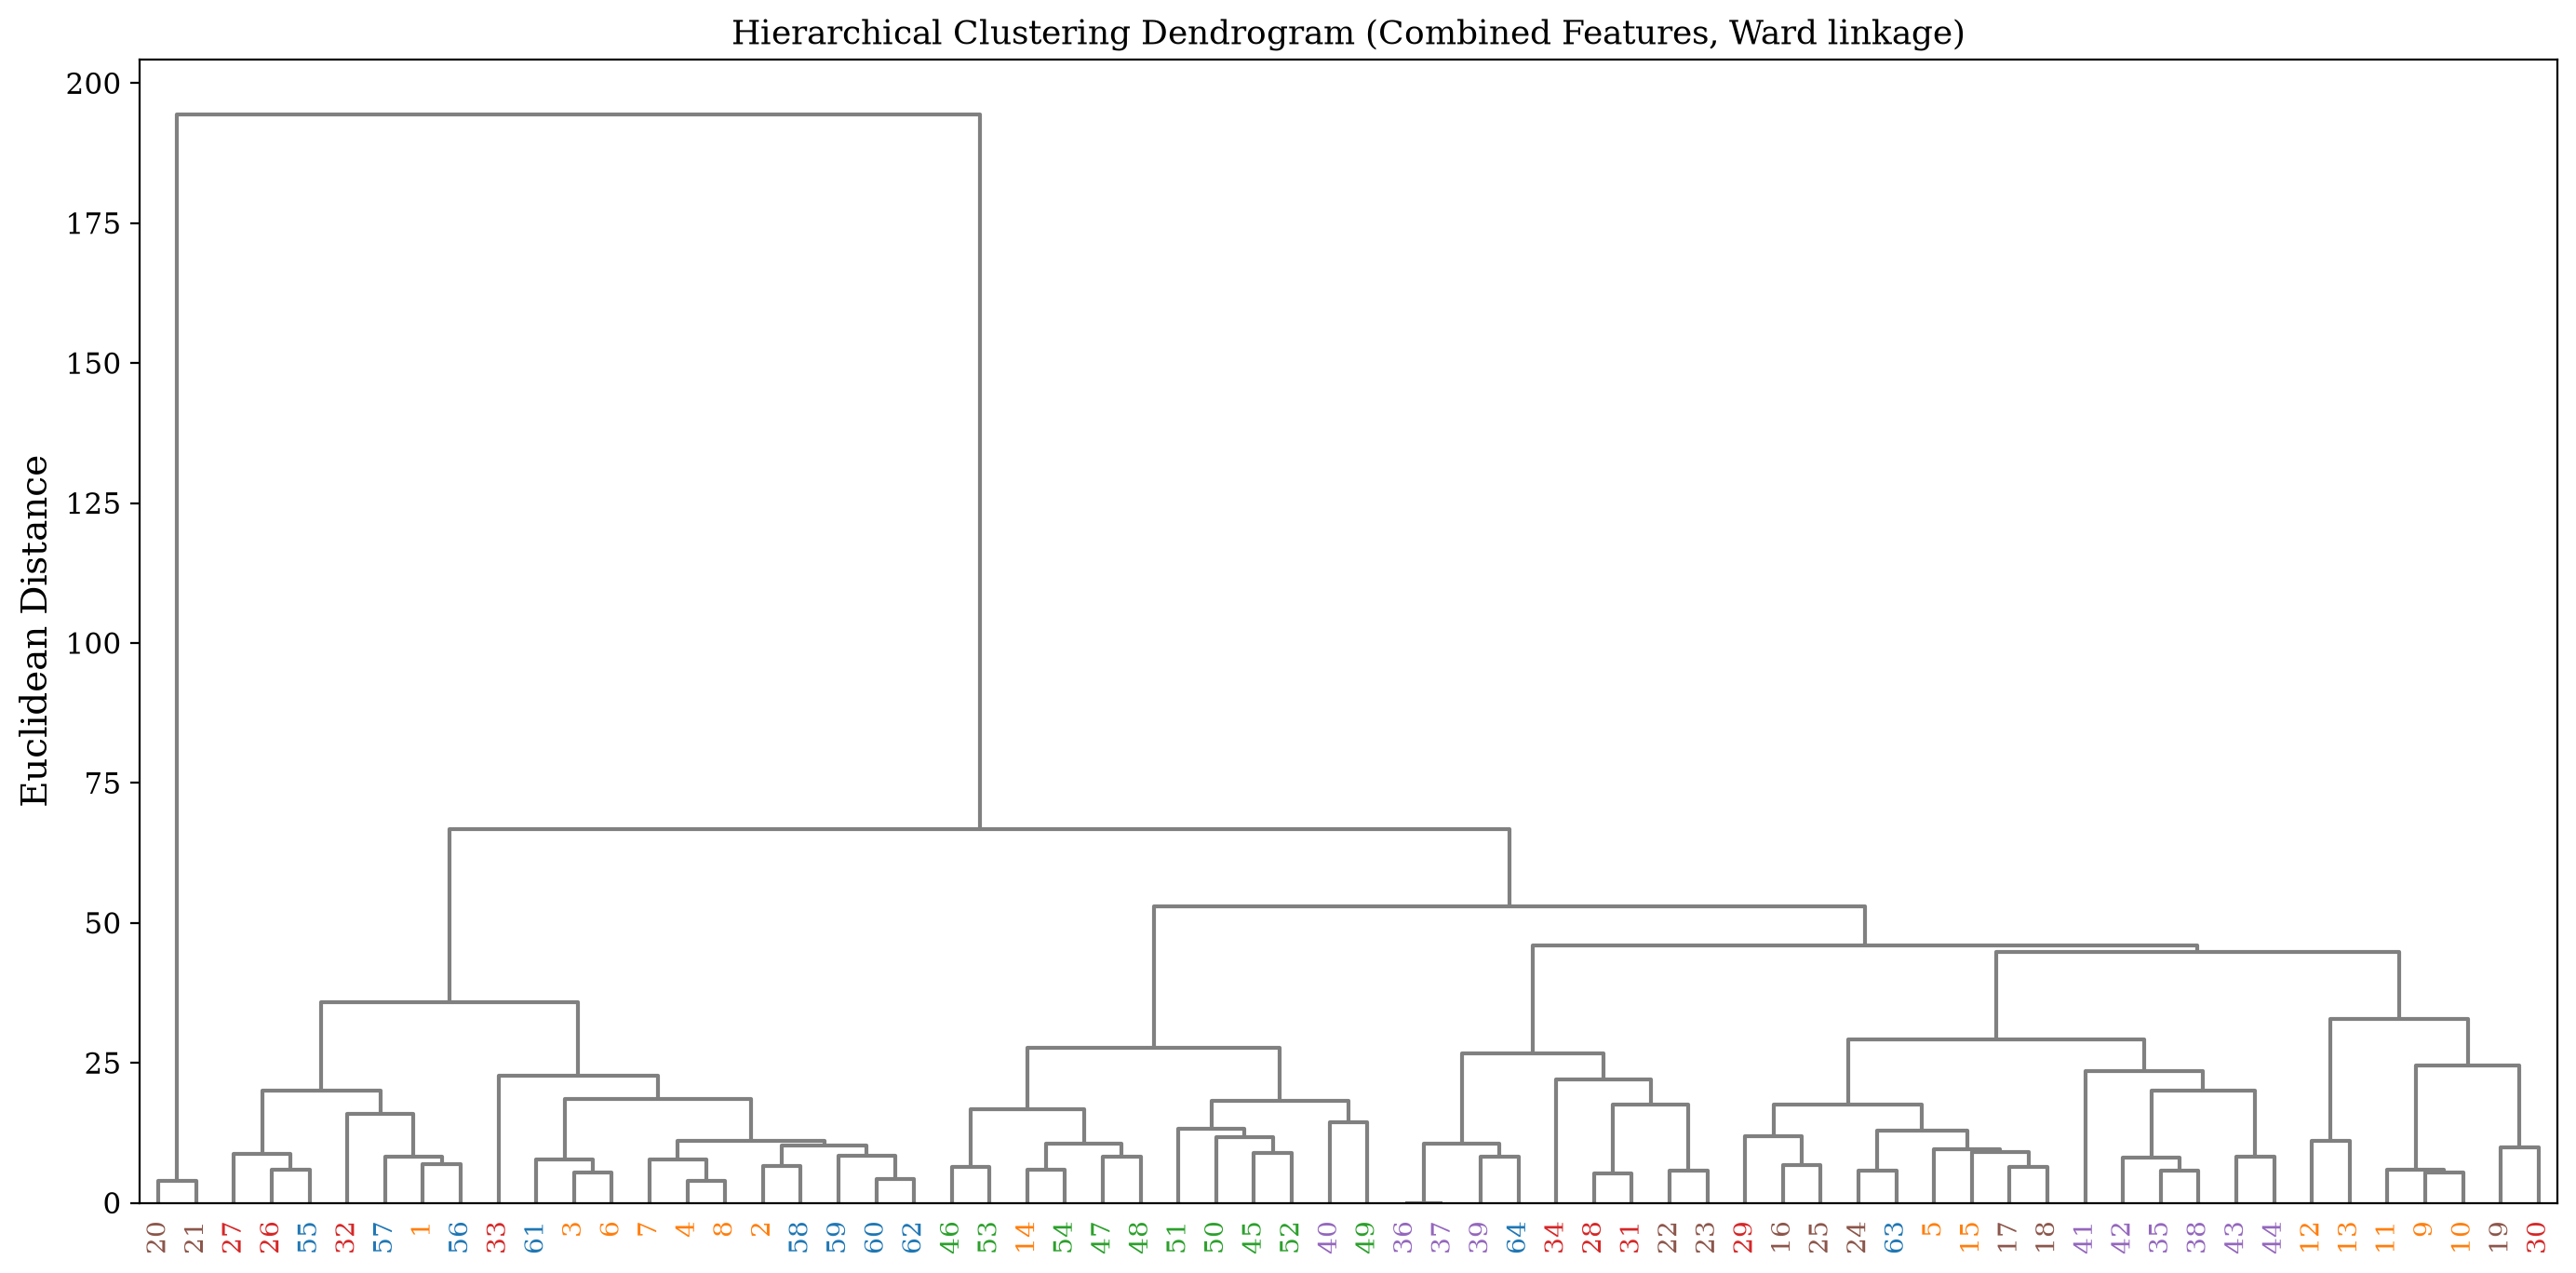

In [23]:
scaler = StandardScaler()
X_autocorr = scaler.fit_transform(autocorr_2d_arrays)
X_ffp = cffp_arrays3.astype(np.float32)
X_combined = np.concatenate([X_ffp, X_autocorr], axis=1)

families = valid_df['family'].values
numbers = valid_df['number'].values

unique_families = np.unique(families)
palette = sns.color_palette('tab10', len(unique_families))
fam2col = dict(zip(unique_families, palette))
colors = [fam2col[f] for f in families]

def plot_pca_tsne_grid(X_list, titles, numbers, colors, families, fam2col):
    fig, axes = plt.subplots(2, 3, figsize=(24,14))
    for col, (X, ttl) in enumerate(zip(X_list, titles)):
        for row, (transform, name) in enumerate(zip(
            [PCA(n_components=2, random_state=42), TSNE(n_components=2, random_state=42, perplexity=10)],
            ['PCA', 't-SNE'])):
            X_2d = transform.fit_transform(X)
            ax = axes[row, col]
            ax.scatter(X_2d[:,0], X_2d[:,1], c=colors, edgecolors='k', s=80, alpha=0.7)
            for i, num in enumerate(numbers):
                ax.annotate(str(num), (X_2d[i,0], X_2d[i,1]), textcoords="offset points", xytext=(4,4), fontsize=7, alpha=0.8)
            ax.set_title(f'{name}: {ttl}')
            if row == 0:
                ax.set_xlabel(f'PC1 ({transform.explained_variance_ratio_[0]:.1%})')
                ax.set_ylabel(f'PC2 ({transform.explained_variance_ratio_[1]:.1%})')
            else:
                ax.set_xlabel('t-SNE 1')
                ax.set_ylabel('t-SNE 2')
    handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=fam2col[f], markersize=8, label=f) for f in unique_families]
    fig.legend(handles=handles, title='Family', loc='upper right', bbox_to_anchor=(1.12,0.95))
    plt.tight_layout()
    plt.show()

X_list = [X_autocorr, X_ffp, X_combined]
titles = ['2D Autocorrelation', 'Functional FPs', 'Combined (FFP + Autocorr)']
plot_pca_tsne_grid(X_list, titles, numbers, colors, families, fam2col)

dist_combined = pdist(X_combined, metric='euclidean')
Z = linkage(dist_combined, method='ward')
plt.figure(figsize=(14,7))
dendrogram(Z, labels=[str(n) for n in numbers], leaf_rotation=90, leaf_font_size=10,
           color_threshold=0, above_threshold_color='gray', link_color_func=lambda k: 'gray')
ax = plt.gca()
for lbl in ax.get_xmajorticklabels():
    idx = np.where(numbers == int(lbl.get_text()))[0][0]
    lbl.set_color(fam2col[families[idx]])
plt.title('Hierarchical Clustering Dendrogram (Combined Features, Ward linkage)')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

In [24]:
#### orig + sinthetic 

Small shape: (341, 216), Deep shape: (20000, 216)
Mean KS p-value: 0.0000


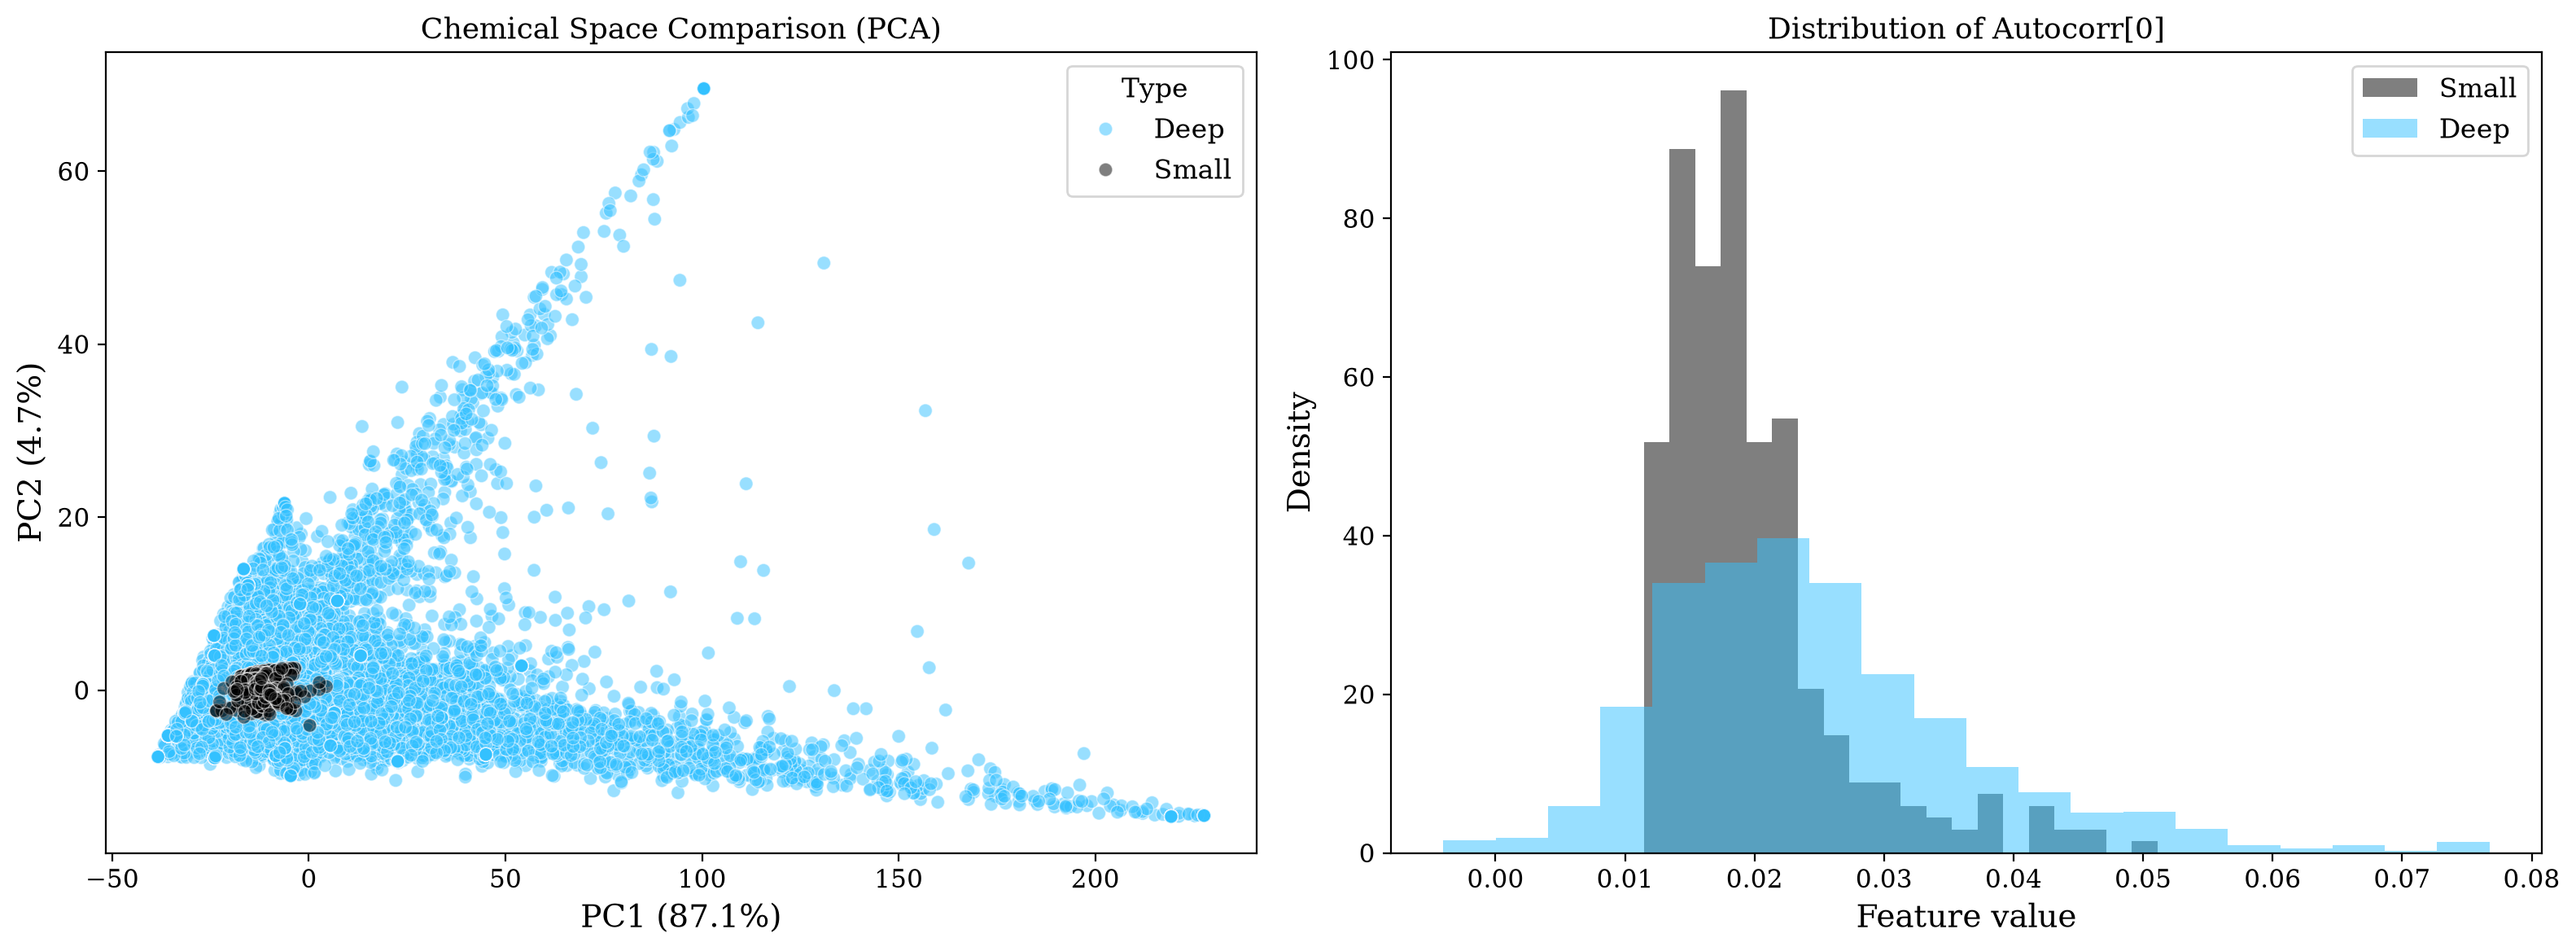

In [25]:
with h5py.File('./data/DL/small_poly_datasets.h5', 'r') as f:
    small_3d = f['autocorr'][:]
with h5py.File('./data/DL/Deep_poly_datasets_Tr.h5', 'r') as f:
    deep_3d = f['autocorr'][:20000]

small_feat = np.mean(small_3d, axis=1)
deep_feat = np.mean(deep_3d, axis=1)
print(f"Small shape: {small_feat.shape}, Deep shape: {deep_feat.shape}")

ks_p = [ks_2samp(small_feat[:, i], deep_feat[:, i])[1] for i in range(min(24, small_feat.shape[1]))]
print(f"Mean KS p-value: {np.mean(ks_p):.4f}")

combined = np.vstack([small_feat, deep_feat])
labels = ['Small'] * len(small_feat) + ['Deep'] * len(deep_feat)
pca = PCA(n_components=2, random_state=42)
pca_res = pca.fit_transform(combined)

df_plot = pd.DataFrame(pca_res, columns=['PC1', 'PC2'])
df_plot['Type'] = labels

df_plot = pd.concat([
    df_plot[df_plot['Type'] == 'Deep'],
    df_plot[df_plot['Type'] == 'Small']
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Type', alpha=0.5,
                palette={'Small': '#000000', 'Deep': '#33C1FF'}, ax=axes[0])
axes[0].set_title('Chemical Space Comparison (PCA)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].hist(small_feat[:, 0], bins=20, alpha=0.5, label='Small', color='#000000', density=True)
axes[1].hist(deep_feat[:, 0], bins=20, alpha=0.5, label='Deep', color='#33C1FF', density=True)
axes[1].set_title('Distribution of Autocorr[0]')
axes[1].set_xlabel('Feature value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# DeepLearning Part

#### Model 

In [4]:
class RoPE(nn.Module):
    def __init__(self, dim, max_len=2048, base=10000.0):
        super().__init__()
        inv = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        pos = torch.arange(max_len).float().unsqueeze(1)
        ang = pos * inv
        self.register_buffer('cos', ang.cos().unsqueeze(0))
        self.register_buffer('sin', ang.sin().unsqueeze(0))

    def forward(self, x):
        n = x.size(1)
        x1, x2 = x[..., 0::2], x[..., 1::2]
        c, s = self.cos[:, :n], self.sin[:, :n]
        return torch.cat([x1*c - x2*s, x1*s + x2*c], dim=-1)

In [5]:
class TransformerVAE_CLS(nn.Module):
    def __init__(self, ffp_dim=256, auto_dim=216, seq_len=1000, d_model=128, nhead=4, num_layers=3, latent_dim=64, dropout=0.1):
        super().__init__()
        self._apply_rope = RoPE(dim=d_model, max_len=1024)
        self.seq_len = seq_len
        self.d_model = d_model
        self.ffp_projection = nn.Linear(ffp_dim, d_model//2)
        self.auto_projection = nn.Linear(auto_dim, d_model//2)
        self.feature_fusion = nn.Linear(d_model, d_model)
        self.ffp_norm = nn.LayerNorm(d_model//2)
        self.auto_norm = nn.LayerNorm(d_model//2)
        self.feature_norm = nn.LayerNorm(d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True, activation=F.mish)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_mu = nn.Linear(d_model, latent_dim)
        self.fc_logvar = nn.Linear(d_model, latent_dim)
        self.fc_decoder_input = nn.Linear(latent_dim, d_model)
        self.decoder_queries = nn.Parameter(torch.randn(1, seq_len, d_model))
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True, activation=F.mish)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_ffp = nn.Sequential(nn.Linear(d_model, ffp_dim), nn.Softplus())
        self.output_auto = nn.Linear(d_model, auto_dim) 

    def encode(self, ffp, auto):
        b = ffp.size(0)
        h_ffp = F.mish(self.ffp_norm(self.ffp_projection(ffp)))
        h_auto = F.mish(self.auto_norm(self.auto_projection(auto)))
        x = self.feature_fusion(torch.cat([h_ffp, h_auto], dim=-1))
        x = self.feature_norm(x)
        x = torch.cat([self.cls_token.expand(b, -1, -1), x], dim=1)
        x = self._apply_rope(x)
        x = self.transformer_encoder(x)
        cls_out = x[:, 0, :]
        return self.fc_mu(cls_out), self.fc_logvar(cls_out)

    def reparameterize(self, mu, logvar):
        if not self.training:
            return mu
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        b = z.size(0)
        memory = self.fc_decoder_input(z).unsqueeze(1)
        tgt = self.decoder_queries.expand(b, -1, -1)
        tgt = self._apply_rope(tgt)
        out = self.transformer_decoder(tgt=tgt, memory=memory)
        return self.output_ffp(out), self.output_auto(out)

    def forward(self, ffp, auto):
        mu, logvar = self.encode(ffp, auto)
        z = self.reparameterize(mu, logvar)
        recon_ffp, recon_auto = self.decode(z)
        return recon_ffp, recon_auto, mu, logvar

In [6]:
class TransformerVAE_SET(nn.Module):
    def __init__(self, ffp_dim=256, auto_dim=216, seq_len=1000, d_model=128, nhead=4, num_layers=3, latent_dim=64, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model
        self.ffp_projection = nn.Linear(ffp_dim, d_model//2)
        self.auto_projection = nn.Linear(auto_dim, d_model//2)
        self.feature_fusion = nn.Linear(d_model, d_model)
        self.ffp_norm = nn.LayerNorm(d_model//2)
        self.auto_norm = nn.LayerNorm(d_model//2)
        self.feature_norm = nn.LayerNorm(d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True, activation=F.mish)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_mu = nn.Linear(d_model, latent_dim)
        self.fc_logvar = nn.Linear(d_model, latent_dim)
        self.fc_decoder_input = nn.Linear(latent_dim, d_model)
        self.decoder_queries = nn.Parameter(torch.randn(1, seq_len, d_model))
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True, activation=F.mish)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_ffp = nn.Sequential(nn.Linear(d_model, ffp_dim), nn.Softplus())
        self.output_auto = nn.Linear(d_model, auto_dim)

    def encode(self, ffp, auto):
        b = ffp.size(0)
        h_ffp = F.mish(self.ffp_norm(self.ffp_projection(ffp)))
        h_auto = F.mish(self.auto_norm(self.auto_projection(auto)))
        x = self.feature_fusion(torch.cat([h_ffp, h_auto], dim=-1))
        x = self.feature_norm(x)
        x = torch.cat([self.cls_token.expand(b, -1, -1), x], dim=1)
        x = self.transformer_encoder(x)
        cls_out = x[:, 0, :]
        return self.fc_mu(cls_out), self.fc_logvar(cls_out)

    def reparameterize(self, mu, logvar):
        if not self.training:
            return mu
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        b = z.size(0)
        memory = self.fc_decoder_input(z).unsqueeze(1)
        tgt = self.decoder_queries.expand(b, -1, -1)
        out = self.transformer_decoder(tgt=tgt, memory=memory)
        return self.output_ffp(out), self.output_auto(out)

    def forward(self, ffp, auto):
        mu, logvar = self.encode(ffp, auto)
        z = self.reparameterize(mu, logvar)
        recon_ffp, recon_auto = self.decode(z)
        return recon_ffp, recon_auto, mu, logvar

In [7]:
class VAE_DeepSets(nn.Module):
    def __init__(self, ffp_dim=256, auto_dim=216, seq_len=1000,
                 d_model=128, nhead=4, num_layers=3, latent_dim=64, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.latent_dim = latent_dim
        self.ffp_dim = ffp_dim
        self.auto_dim = auto_dim
        in_features = ffp_dim + auto_dim
        self.element_net = nn.Sequential(nn.Linear(in_features, d_model),nn.LayerNorm(d_model), nn.Mish(), nn.Linear(d_model, d_model), nn.LayerNorm(d_model))
        self.global_net = nn.Sequential(nn.Linear(d_model, d_model),nn.LayerNorm(d_model), nn.Mish(), nn.Linear(d_model, latent_dim * 2))
        self.slots = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.2)
        self.shared_decoder = nn.Sequential(nn.Linear(latent_dim + d_model, d_model),nn.LayerNorm(d_model),nn.Mish(),nn.Linear(d_model, ffp_dim + auto_dim))

    def encode(self, ffp, auto):
        x = torch.cat([ffp, auto], dim=-1)          
        x = self.element_net(x)                     
        x_pool = x.mean(dim=1)                       
        out = self.global_net(x_pool)               
        mu, logvar = out.chunk(2, dim=-1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if not self.training:
            return mu
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        b = z.size(0)
        z_exp = z.unsqueeze(1).expand(-1, self.seq_len, -1)   
        slots = self.slots.expand(b, -1, -1)                
        combined = torch.cat([z_exp, slots], dim=-1)        
        out = self.shared_decoder(combined)                  
        recon_ffp = F.softplus(out[..., :self.ffp_dim])
        recon_auto = out[..., self.ffp_dim:]
        return recon_ffp, recon_auto

    def forward(self, ffp, auto):
        mu, logvar = self.encode(ffp, auto)
        z = self.reparameterize(mu, logvar)
        recon_ffp, recon_auto = self.decode(z)
        return recon_ffp, recon_auto, mu, logvar

#### loss

In [12]:
def chamfer_distance(source, target):
    dist = torch.cdist(source, target, p=2, compute_mode="use_mm_for_euclid_dist_if_necessary").pow(2)
    src_to_tgt_min, _ = torch.min(dist, dim=-1)
    tgt_to_src_min, _ = torch.min(dist, dim=-2)
    chamfer_loss = torch.mean(src_to_tgt_min) + torch.mean(tgt_to_src_min)
    
    return chamfer_loss


def loss_function_set(recon_ffp, ffp_true, recon_auto, auto_true, mu, logvar, beta=1.0):
    ffp_loss = chamfer_distance(recon_ffp/50.0, ffp_true/50.0)
    auto_loss = chamfer_distance(recon_auto/110.0, auto_true/110.0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.numel()
    total = ffp_loss*15 + auto_loss*10 + beta * kl
    return total, ffp_loss, auto_loss, kl

def loss_function_cls(recon_ffp, ffp_true, recon_auto, auto_true, mu, logvar, beta=1.0):
    ffp_loss = F.poisson_nll_loss(recon_ffp, ffp_true.float(), log_input=False, full=True, reduction='mean')
    auto_loss = F.mse_loss(recon_auto, auto_true.float())
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.numel()
    total = 10*ffp_loss + auto_loss + beta * kl_loss
    return total, ffp_loss, auto_loss, kl_loss

## Train

In [13]:
class PolymerDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(self.h5_path, 'r') as f:
            self.length = f['cffp_256'].shape[0]
        self.file = None
        self.ffp = None
        self.auto = None

    def __len__(self):
        return self.length

    def _init_h5(self):
        if self.file is None:
            self.file = h5py.File(self.h5_path, 'r')
            self.ffp = self.file['cffp_256']
            self.auto = self.file['autocorr']

    def __getitem__(self, idx):
        self._init_h5()
        ffp_sample = self.ffp[idx]
        auto_sample = self.auto[idx]
        return (torch.from_numpy(ffp_sample).float(),
                torch.from_numpy(auto_sample).float())

    def close(self):
        if self.file is not None:
            self.file.close()
            self.file = None

In [14]:
#sinkhorn_eval = SamplesLoss("sinkhorn", p=2, blur=0.05, scaling=0.95)

In [15]:
def train(model, train_loader, val_loader, epochs, lr, beta, device, model_name, loss_fn,
          warmup_epochs=15, start_beta=0.0, patience=10):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    best_val_loss = float('inf')
    no_improve = 0

    writer = SummaryWriter(log_dir=f"runs/{model_name}_VAE")
    
    history = {'train_loss': [], 'val_loss': [], 'val_recon': [], 'val_geom': [],
               'val_ffp': [], 'val_auto': [], 'val_kl': [], 'beta': []}

    for epoch in range(1, epochs+1):
        epoch_start = time.time() 
        current_beta = start_beta + (beta - start_beta) * (epoch - 1) / max(1, warmup_epochs - 1) if epoch <= warmup_epochs else beta
        history['beta'].append(current_beta)
        train_start = time.time()                   
        model.train()
        train_loss_sum = torch.tensor(0.0, device=device)
        train_ffp_sum  = torch.tensor(0.0, device=device)
        train_auto_sum = torch.tensor(0.0, device=device)
        train_kl_sum   = torch.tensor(0.0, device=device)
        for ffp, auto in train_loader:
            ffp, auto = ffp.to(device), auto.to(device)
            optimizer.zero_grad()
            recon_ffp, recon_auto, mu, logvar = model(ffp, auto)
            loss, f_loss, a_loss, kl_loss = loss_fn(recon_ffp, ffp, recon_auto, auto, mu, logvar, current_beta)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            bs = ffp.size(0)
            train_loss_sum += loss.detach() * bs
            train_ffp_sum  += f_loss.detach() * bs
            train_auto_sum += a_loss.detach() * bs
            train_kl_sum   += kl_loss.detach() * bs

        n_train = len(train_loader.dataset)
        avg_train = train_loss_sum.item() / n_train
        avg_train_ffp   = train_ffp_sum.item() / n_train
        avg_train_auto  = train_auto_sum.item() / n_train
        avg_train_kl    = train_kl_sum.item() / n_train
        avg_train_recon = avg_train_ffp + avg_train_auto
        
        train_time = time.time() - train_start
        val_start = time.time()                     
        model.eval()
        val_loss_sum = torch.tensor(0.0, device=device)
        val_ffp_sum  = torch.tensor(0.0, device=device)
        val_auto_sum = torch.tensor(0.0, device=device)
        val_kl_sum   = torch.tensor(0.0, device=device)
        val_geom_cpu = 0.0

        with torch.no_grad():
            for ffp, auto in val_loader:
                ffp, auto = ffp.to(device), auto.to(device)
                recon_ffp, recon_auto, mu, logvar = model(ffp, auto)
                loss, f_loss, a_loss, kl_loss = loss_fn(recon_ffp, ffp, recon_auto, auto, mu, logvar, current_beta)
                bs = ffp.size(0)
                val_loss_sum += loss.detach() * bs
                val_ffp_sum  += f_loss.detach() * bs
                val_auto_sum += a_loss.detach() * bs
                val_kl_sum   += kl_loss.detach() * bs

                geom_ffp_val = chamfer_distance(recon_ffp.float(), ffp.float()).item()
                geom_auto_val = chamfer_distance(recon_auto.float(), auto.float()).item()
                val_geom_cpu += (geom_ffp_val + geom_auto_val) * bs

        n_val = len(val_loader.dataset)
        avg_val  = val_loss_sum.item() / n_val
        avg_ffp  = val_ffp_sum.item() / n_val
        avg_auto = val_auto_sum.item() / n_val
        avg_kl   = val_kl_sum.item() / n_val
        avg_recon = avg_ffp + avg_auto
        avg_geom  = val_geom_cpu / n_val
        val_time = time.time() - val_start
        for k, v in zip(['train_loss','val_loss','val_recon','val_geom','val_ffp','val_auto','val_kl'],
                        [avg_train, avg_val, avg_recon, avg_geom, avg_ffp, avg_auto, avg_kl]):
            history[k].append(v)
        writer.add_scalars("Loss/Total", {"Train": avg_train, "Validation": avg_val}, epoch)
        writer.add_scalars("Loss/Reconstruction_Total", {"Train": avg_train_recon, "Validation": avg_recon}, epoch)
        writer.add_scalars("Loss/FFP_Component", {"Train": avg_train_ffp, "Validation": avg_ffp}, epoch)
        writer.add_scalars("Loss/Auto_Component", {"Train": avg_train_auto, "Validation": avg_auto}, epoch)
        writer.add_scalars("Loss/KL_Divergence", {"Train": avg_train_kl, "Validation": avg_kl}, epoch)
        writer.add_scalar("Metric/Validation_Geometry", avg_geom, epoch)
        writer.add_scalar("Hyperparameters/Beta", current_beta, epoch)
        writer.add_scalar("Hyperparameters/Learning_Rate", optimizer.param_groups[0]['lr'], epoch)
        if epoch == 1 or epoch % 5 == 0:
            for name, param in model.named_parameters():
                tb_name = name.replace('.', '/')
                writer.add_histogram(f"Weights/{tb_name}", param.data, epoch)
                if param.grad is not None:
                    writer.add_histogram(f"Gradients/{tb_name}", param.grad.data, epoch)
        
        epoch_time = time.time() - epoch_start
        print(f"{model_name} | Epoch {epoch:3d} | β: {current_beta:.3f} | "
              f"Tr: {avg_train:.4f} | Val: {avg_val:.4f} | Recon: {avg_recon:.4f} | Geom: {avg_geom:.4f} | "
              f"ffp: {avg_ffp:.4f} auto: {avg_auto:.4f} KL: {avg_kl:.4f}"
              f"Time: {epoch_time:.1f}s (train {train_time:.1f}s, val {val_time:.1f}s)")

        if epoch > warmup_epochs:
            scheduler.step(avg_val)
            if avg_val < best_val_loss:
                best_val_loss = avg_val
                no_improve = 0
                torch.save(model.state_dict(), f"./data/DL/models/{model_name}_VAE.pt")
            else:
                no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
                
    writer.close()
    return history

In [ ]:
model_config = {
    'ffp_dim': 256,
    'auto_dim': 216,
    'seq_len': 1000,
    'd_model': 128,
    'nhead': 4,
    'num_layers': 3,
    'latent_dim': 64,
    'dropout': 0.1,
}

train_config = {
    'batch_size': 32,
    'epochs': 100,
    'lr': 2e-4,
    'beta': 1.0,
    'warmup_epochs': 15,
    'start_beta': 0.0,
    'patience': 10,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = PolymerDataset('./data/DL/Deep_poly_datasets_Tr.h5')
val_ds   = PolymerDataset('./data/DL/Deep_poly_datasets_Val.h5')

train_loader = DataLoader(train_ds, batch_size=train_config['batch_size'], shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=train_config['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

model_factories = {
#    'CLS': lambda: TransformerVAE_CLS(**model_config),
    'SET': lambda: TransformerVAE_SET(**model_config),
    'DS':  lambda: VAE_DeepSets(**model_config),
}

loss_fns = {
#    'CLS': loss_function_cls,
    'SET': loss_function_set,
    'DS':  loss_function_set,
}

histories = {}

for name, create_model in model_factories.items():
    print(f"\n{'='*50}\nTraining {name}\n{'='*50}")
    
    model = create_model().to(device)
    
    histories[name] = train(
        model, train_loader, val_loader,
        epochs=train_config['epochs'],
        lr=train_config['lr'],
        beta=train_config['beta'],
        device=device,
        model_name=name,
        loss_fn=loss_fns[name],
        warmup_epochs=train_config['warmup_epochs'],
        start_beta=train_config['start_beta'],
        patience=train_config['patience']
    )
    
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

train_ds.close()
val_ds.close()

print(f"\n{'='*50}\nFinal Results:\n{'='*50}")
for name, hist in histories.items():
    last_geom = hist['val_geom'][-1]
    print(f"{name}: final val_geom = {last_geom:.6f}")



Training SET
SET | Epoch   1 | β: 0.000 | Tr: 0.4430 | Val: 0.0892 | Recon: 0.0075 | Geom: 63.7596 | ffp: 0.0028 auto: 0.0047 KL: 3.5309Time: 7112.2s (train 6625.3s, val 486.3s)
SET | Epoch   2 | β: 0.071 | Tr: 0.1400 | Val: 0.0868 | Recon: 0.0054 | Geom: 46.0113 | ffp: 0.0020 auto: 0.0034 KL: 0.3227Time: 10239.1s (train 9855.7s, val 383.4s)
SET | Epoch   3 | β: 0.143 | Tr: 0.1146 | Val: 0.0840 | Recon: 0.0047 | Geom: 40.6791 | ffp: 0.0017 auto: 0.0030 KL: 0.2014Time: 4784.0s (train 4401.4s, val 382.6s)
SET | Epoch   4 | β: 0.214 | Tr: 0.1097 | Val: 0.0792 | Recon: 0.0038 | Geom: 31.8258 | ffp: 0.0015 auto: 0.0023 KL: 0.1590Time: 8478.8s (train 7973.9s, val 504.9s)
SET | Epoch   5 | β: 0.286 | Tr: 0.1110 | Val: 0.0851 | Recon: 0.0038 | Geom: 33.0917 | ffp: 0.0014 auto: 0.0025 KL: 0.1397Time: 4764.4s (train 4381.7s, val 381.0s)
SET | Epoch   6 | β: 0.357 | Tr: 0.1192 | Val: 0.0935 | Recon: 0.0040 | Geom: 34.4778 | ffp: 0.0014 auto: 0.0026 KL: 0.1310Time: 5077.1s (train 4696.6s, val 380

## loading

In [34]:
def load_pretrained_vae(model_type, checkpoint_path, device):
    model_config = {
        'ffp_dim': 256,
        'auto_dim': 216,
        'seq_len': 1000,
        'd_model': 128,
        'nhead': 4,
        'num_layers': 3,
        'latent_dim': 64,
        'dropout': 0.1,
    }

    models = {
        "CLS": TransformerVAE_CLS,
        "SET": TransformerVAE_SET,
        "DS": VAE_DeepSets,
    }

    vae = models[model_type](**model_config)
    state_dict = torch.load(checkpoint_path, map_location=device)
    vae.load_state_dict(state_dict)
    vae.to(device)
    vae.eval()

    return vae

In [35]:
class H5LatentDataset(Dataset):
    def __init__(self, h5_path):
        self.file = h5py.File(h5_path, 'r')
        self.ffp = self.file['cffp_256']
        self.auto = self.file['autocorr']

    def __len__(self):
        return self.ffp.shape[0]

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.ffp[idx]).float(),
            torch.from_numpy(self.auto[idx]).float()
        )

    def close(self):
        self.file.close()

def save_latent_vectors_npy(
    model_type,        # "CLS", "SET", "DS"
    checkpoint_path,   # .pt 
    h5_input_path,     # HDF5
    output_npy_path,   # latent_vectors.npy
    device,
    batch_size=32
):
    vae = load_pretrained_vae(model_type, checkpoint_path, device)
    vae.eval()

    dataset = H5LatentDataset(h5_input_path)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    all_mu = []
    with torch.no_grad():
        for ffp, auto in loader:
            ffp, auto = ffp.to(device), auto.to(device)
            mu, _ = vae.encode(ffp, auto)
            all_mu.append(mu.cpu().numpy())

    all_mu = np.concatenate(all_mu, axis=0)
    np.save(output_npy_path, all_mu)
    print(f" {len(all_mu)} --- {output_npy_path}")
    dataset.close()
    return all_mu

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_latent_vectors_npy(
    model_type="CLS",
    checkpoint_path="./data/DL/models/CLS_VAE.pt",
    h5_input_path="./data/DL/small_poly_datasets.h5",
    output_npy_path="./data/ML/npys/CLS_no_compressed.npy",
    device=device,
    batch_size=32
)

 341 --- CLS_no_compressed.npy


array([[ 0.00299594,  0.01025593,  0.21451773, ...,  0.00802714,
        -0.00908358,  0.56001645],
       [ 0.0082136 ,  0.00395516,  0.1866921 , ...,  0.00335032,
        -0.01738151,  0.34427106],
       [ 0.00228727,  0.00530393,  0.07064304, ...,  0.00952268,
        -0.00904704,  0.6206724 ],
       ...,
       [ 0.00826592,  0.01746053,  0.53701323, ..., -0.01994231,
        -0.00949099,  0.36210525],
       [ 0.00658866,  0.0176102 ,  0.48389465, ..., -0.01979831,
        -0.008582  ,  0.37212363],
       [ 0.01186942,  0.01678887,  0.5911509 , ..., -0.02092465,
        -0.01203648,  0.2726135 ]], shape=(341, 64), dtype=float32)

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_latent_vectors_npy(
    model_type="SET",
    checkpoint_path="./data/DL/models/SET_VAE.pt",
    h5_input_path="./data/DL/small_poly_datasets.h5",
    output_npy_path="./data/ML/npys/SET_no_compressed.npy",
    device=device,
    batch_size=32
)

 341 --- SET_no_compressed.npy


array([[-0.00094438, -0.00017034,  0.00570882, ..., -0.0025976 ,
        -0.00462037,  0.00324993],
       [-0.00108919, -0.00027168,  0.00615372, ..., -0.00273626,
        -0.00452709,  0.00316603],
       [-0.00062618, -0.00021125,  0.00520184, ..., -0.00244948,
        -0.00465367,  0.00317934],
       ...,
       [-0.00293495, -0.00172276,  0.00977272, ..., -0.00427489,
        -0.00439773,  0.00307199],
       [-0.00304881, -0.00173979,  0.00977037, ..., -0.00432056,
        -0.00443235,  0.00313773],
       [-0.00271095, -0.0016584 ,  0.00980303, ..., -0.00417076,
        -0.00432598,  0.00293802]], shape=(341, 64), dtype=float32)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_latent_vectors_npy(
    model_type="DS",
    checkpoint_path="./data/DL/models/DS_VAE.pt",
    h5_input_path="./data/DL/small_poly_datasets.h5",
    output_npy_path="./data/ML/npys/DS_no_compressed.npy",
    device=device,
    batch_size=32
)

 341 --- DS_no_compressed.npy


array([[-6.2934309e-03,  5.8118729e-03, -1.6179346e-03, ...,
         1.5859101e-03, -6.8452582e-04,  1.1909902e-03],
       [-6.1026439e-03,  5.7284934e-03, -1.5455931e-03, ...,
         1.6098004e-03, -7.1396679e-04,  1.1926889e-03],
       [-6.6567287e-03,  6.0598245e-03, -1.7357171e-03, ...,
         1.3600849e-03, -1.2752153e-03,  1.0973662e-03],
       ...,
       [-8.8171288e-04,  3.0759992e-03, -2.1932796e-03, ...,
         1.1412092e-03,  2.5111325e-03,  2.1554083e-03],
       [-1.2221597e-03,  3.0219918e-03, -2.0425990e-03, ...,
         1.1502281e-03,  2.6761880e-03,  1.8708259e-03],
       [ 9.8101795e-05,  3.3731302e-03, -2.5083311e-03, ...,
         1.2970474e-03,  1.9800141e-03,  2.9947013e-03]],
      shape=(341, 64), dtype=float32)

In [36]:
def generate_latent_h5(
    model_type: str,
    checkpoint_path: str,
    device: torch.device,
    ffp_list: List[np.ndarray],
    auto_list: List[np.ndarray],
    output_h5_path: str,
    total_samples: int,
    seq_len: int,
    batch_size: int = 5000,
    max_monomers: int = 7,
) -> None:
    np.random.seed(SEED)
    
    vae = load_pretrained_vae(model_type, checkpoint_path, device)
    vae.eval()
    num_monomers = len(ffp_list)
    ffp_arr = np.array(ffp_list, dtype=np.float32)
    auto_arr = np.array(auto_list, dtype=np.float32)
    
    with torch.no_grad():
        dummy_ffp = torch.from_numpy(ffp_arr[:1]).repeat(1, seq_len, 1).to(device)
        dummy_auto = torch.from_numpy(auto_arr[:1]).repeat(1, seq_len, 1).to(device)
        mu_dummy, _ = vae.encode(dummy_ffp, dummy_auto)
        latent_dim = mu_dummy.shape[1]
    
    with h5py.File(output_h5_path, 'w') as f:
        frac_dset = f.create_dataset('fractions', shape=(0, num_monomers), maxshape=(None, num_monomers), dtype=np.float32, compression='gzip', compression_opts=4)
        mu_dset = f.create_dataset('mu', shape=(0, latent_dim), maxshape=(None, latent_dim), dtype=np.float32, compression='gzip', compression_opts=4)
        pbar = tqdm(total=total_samples, desc="Generating")
        for start in range(0, total_samples, batch_size):
            end = min(start + batch_size, total_samples)
            cur_batch = end - start
            frac_batch = np.empty((cur_batch, num_monomers), dtype=np.float32)
            mu_batch = np.empty((cur_batch, latent_dim), dtype=np.float32)
            ffp_arr_local = ffp_arr
            auto_arr_local = auto_arr
            n_monomers = num_monomers
            seq_len_local = seq_len
            
            for i in range(cur_batch):
                k = np.random.randint(1, min(max_monomers, n_monomers) + 1)
                idxs = np.random.choice(n_monomers, size=k, replace=False)
                r = np.random.dirichlet(np.ones(k))
                
                frac_i = np.zeros(n_monomers, dtype=np.float32)
                frac_i[idxs] = r
                frac_batch[i] = frac_i
                
                picks = np.random.choice(idxs, size=seq_len_local, p=r)
                ffp_seq = ffp_arr_local[picks]
                auto_seq = auto_arr_local[picks]
                
                ffp_t = torch.from_numpy(ffp_seq).unsqueeze(0).to(device)
                auto_t = torch.from_numpy(auto_seq).unsqueeze(0).to(device)
                with torch.no_grad():
                    mu_i, _ = vae.encode(ffp_t, auto_t)
                mu_batch[i] = mu_i.squeeze(0).cpu().numpy()
            
            frac_dset.resize(frac_dset.shape[0] + cur_batch, axis=0)
            mu_dset.resize(mu_dset.shape[0] + cur_batch, axis=0)
            frac_dset[-cur_batch:] = frac_batch
            mu_dset[-cur_batch:] = mu_batch
            
            pbar.update(cur_batch)
        pbar.close()
    
    print(f"Save to {output_h5_path}")

In [39]:
ffp_list = valid_df['cffp_256'].tolist()
auto_list = valid_df['autocorr'].tolist()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = ['CLS', 'SET', 'DS']
checkpoints = {m: f'./data/DL/models/{m}_VAE.pt' for m in models}
outputs = {m: f'./data/DL/latent_db_{m}.h5' for m in models}

for model in models:
    print(f"\nGenerating latent database for {model}...")
    generate_latent_h5(
        model_type=model,
        checkpoint_path=checkpoints[model],
        device=device,
        ffp_list=ffp_list,
        auto_list=auto_list,
        output_h5_path=outputs[model],
        total_samples=2000000,
        seq_len=1000,
        batch_size=16,
        max_monomers=7
    )
    print(f"Done: {outputs[model]}")


Generating latent database for CLS...


Generating: 100%|██████████████████| 2000000/2000000 [6:27:03<00:00, 86.12it/s]


Save to latent_db_CLS.h5
Done: latent_db_CLS.h5

Generating latent database for SET...


Generating: 100%|█████████████████| 2000000/2000000 [3:21:15<00:00, 165.62it/s]


Save to latent_db_SET.h5
Done: latent_db_SET.h5

Generating latent database for DS...


Generating: 100%|█████████████████| 2000000/2000000 [1:11:00<00:00, 469.41it/s]


Save to latent_db_DS.h5
Done: latent_db_DS.h5


## Metrics

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### learning losses of 3 models

In [19]:
def plot_training_history(histories):
    metrics = [
        ('train_loss', 'Train Total Loss'), ('val_loss', 'Val Total Loss'),
        ('val_recon', 'Val Recon Loss (ffp+auto)'), ('val_ffp', 'Val FFP Loss'),
        ('val_auto', 'Val Auto Loss'), ('val_kl', 'Val KL Divergence'),
        ('val_geom', 'Val Geometry (Chamfer)')
    ]
    fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 4*len(metrics)))
    for row, (key, title) in enumerate(metrics):
        ax1, ax2 = axes[row, 0], axes[row, 1]
        for model_name, hist in histories.items():
            values = np.where(np.isfinite(hist[key]), np.array(hist[key]), np.nan)
            epochs = np.arange(1, len(values)+1)
            ax1.plot(epochs, values, label=model_name, linewidth=1.5)
            ax2.plot(epochs, np.abs(values), label=model_name, linewidth=1.5)
        ax1.set_title(f'{title} (linear)'); ax1.set_xlabel('Epoch'); ax1.grid(True, alpha=0.3); ax1.legend()
        ax2.set_title(f'{title} (log)'); ax2.set_xlabel('Epoch'); ax2.grid(True, alpha=0.3); ax2.legend(); ax2.set_yscale('log')
    plt.figure(figsize=(10,4))
    for model_name, hist in histories.items():
        betas = hist['beta']
        plt.plot(range(1, len(betas)+1), betas, label=model_name, linewidth=2)
    plt.title('Beta Warm-up Schedule'); plt.xlabel('Epoch'); plt.ylabel('Beta'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

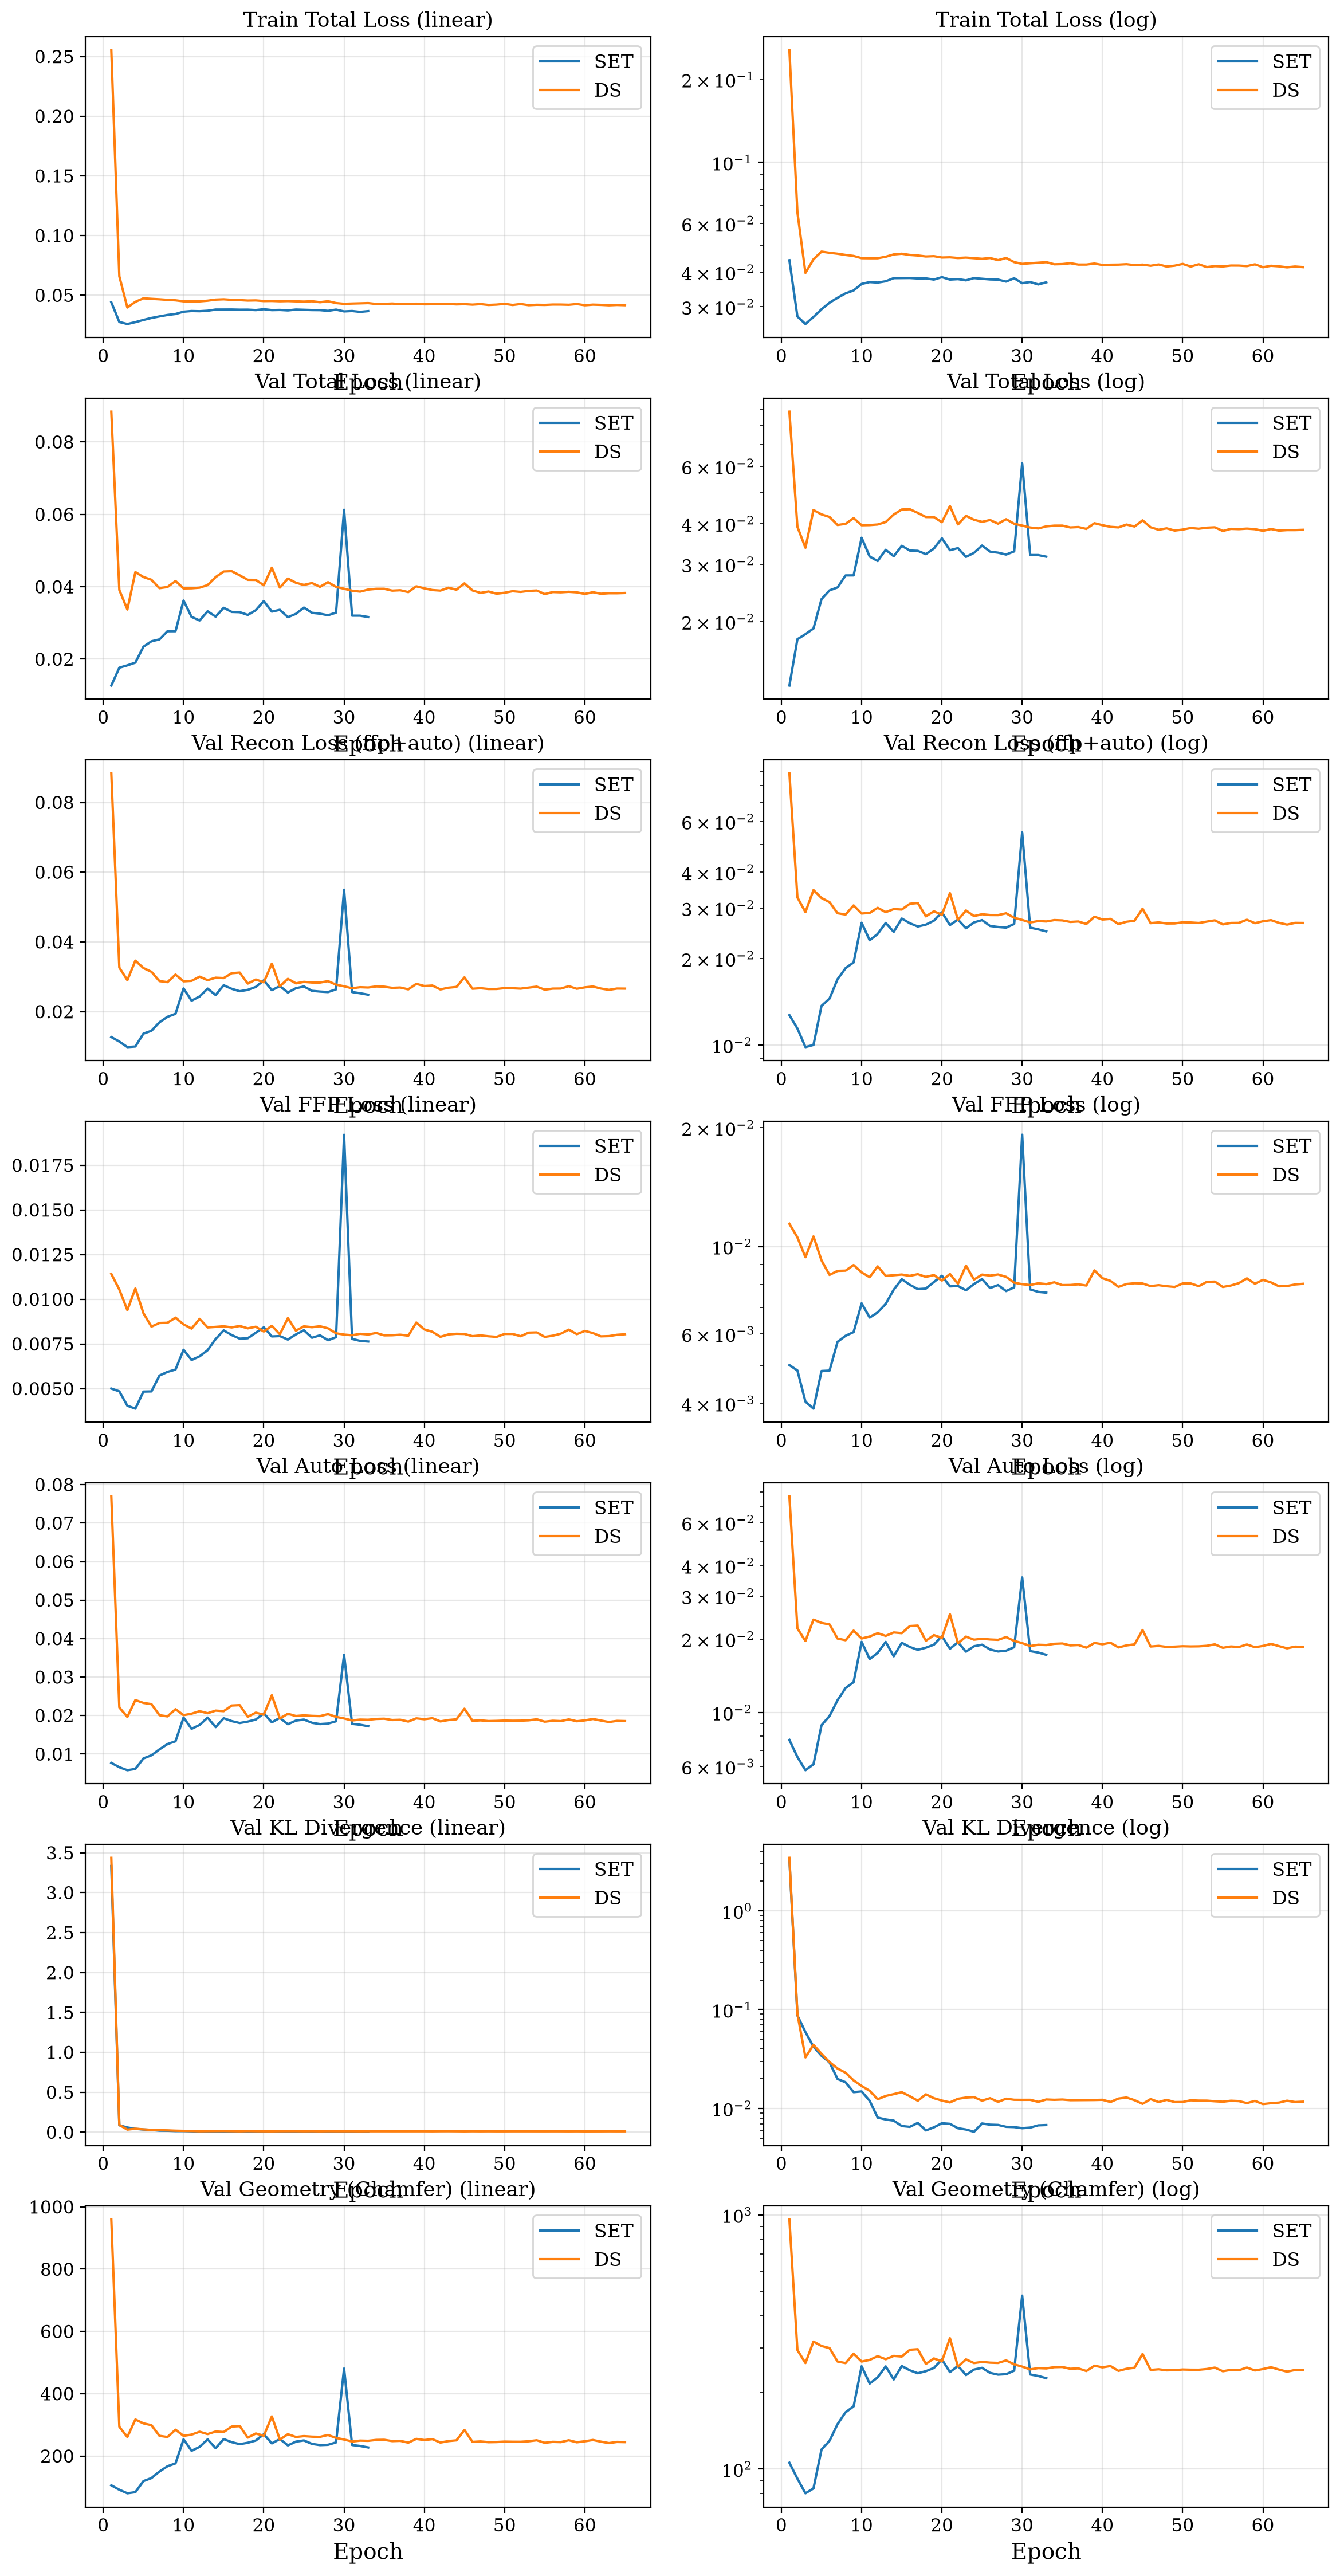

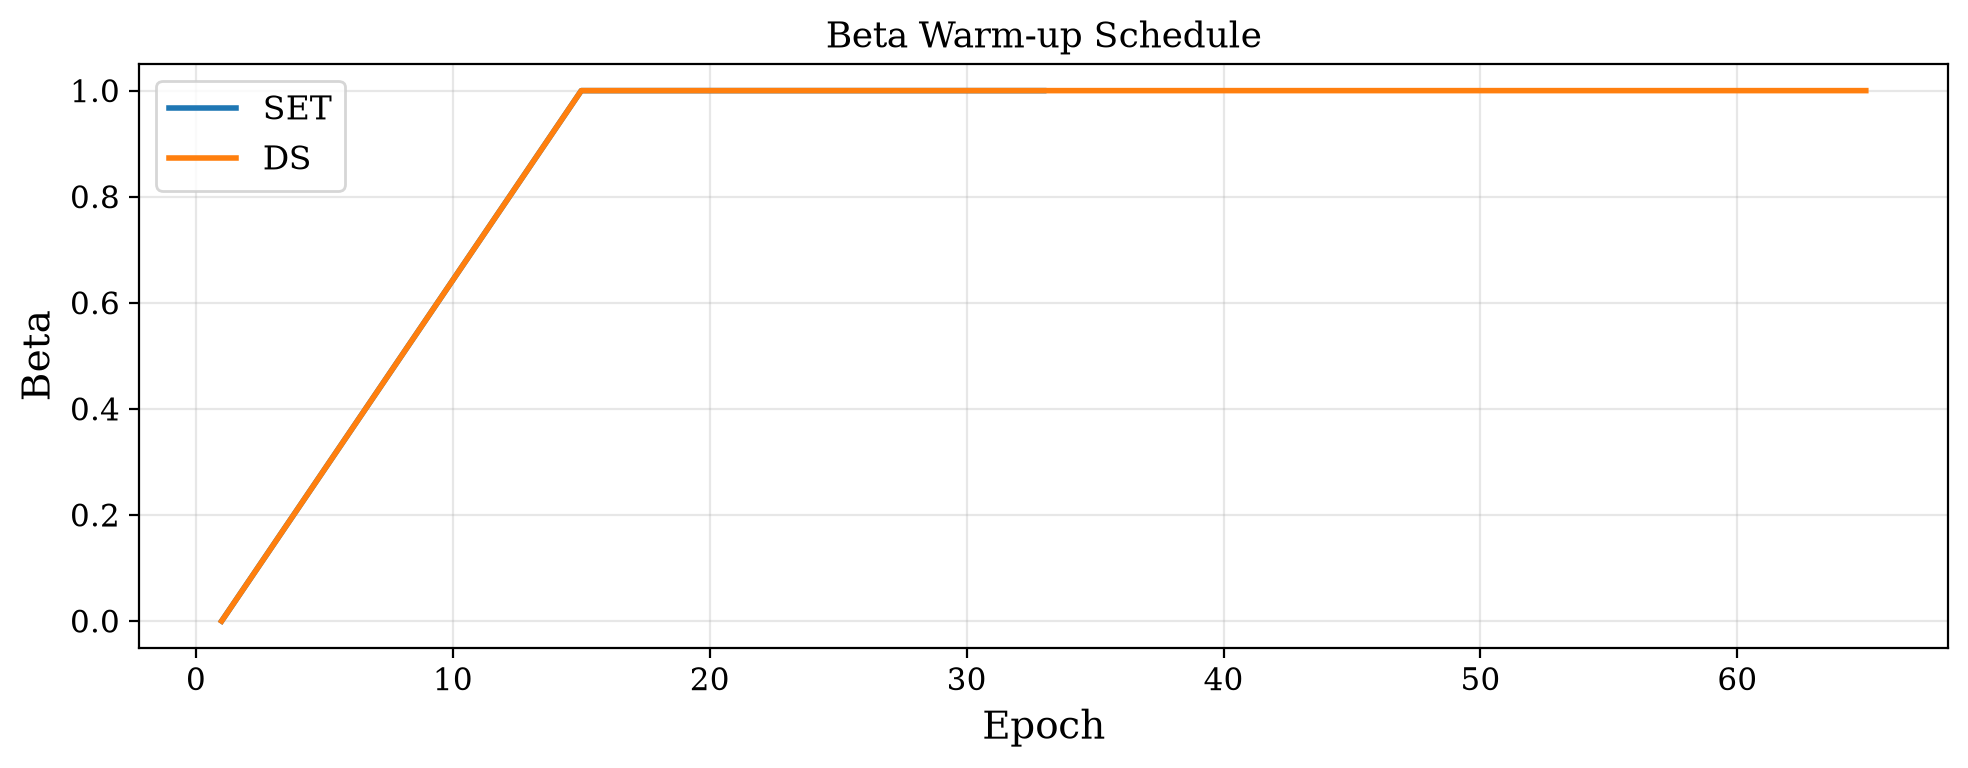

In [20]:
plot_training_history(histories)

#### Latent space analyze for models

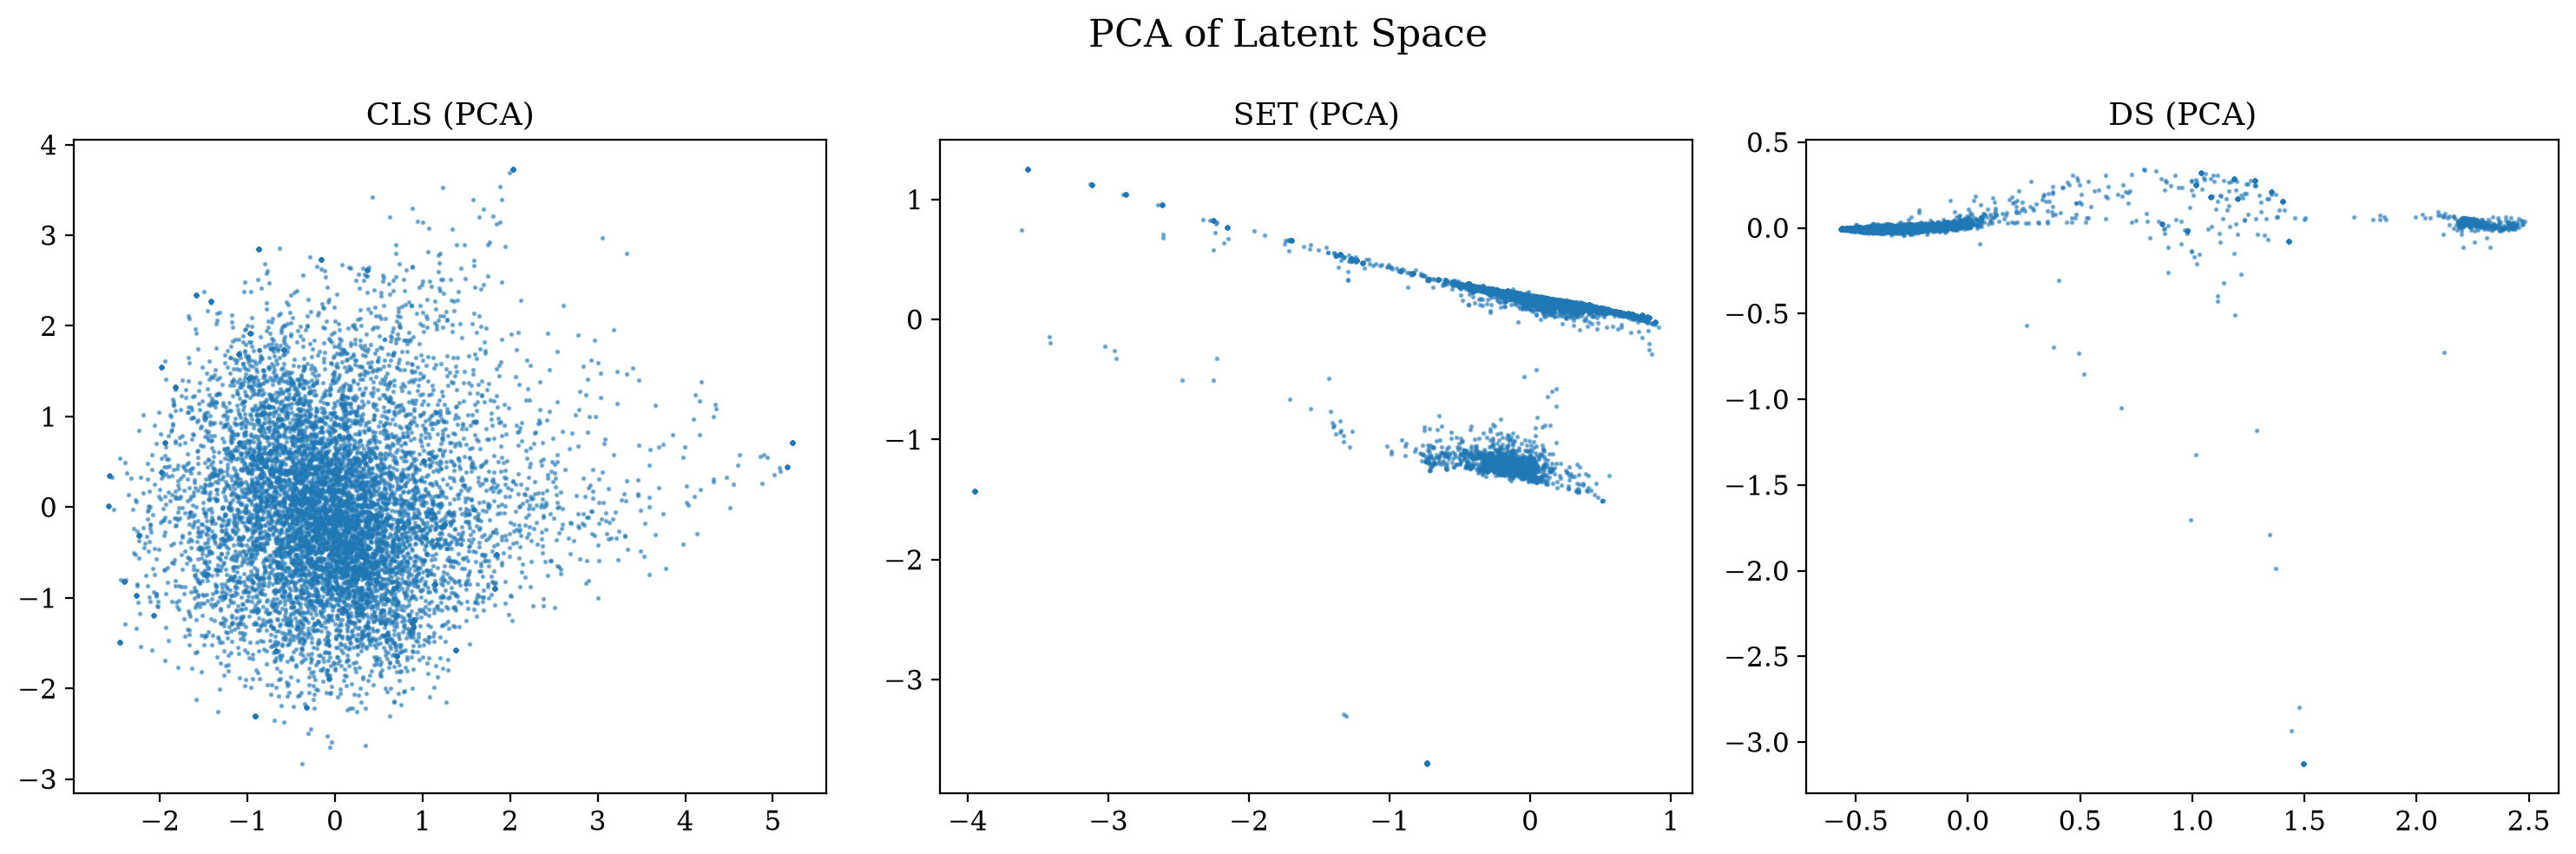

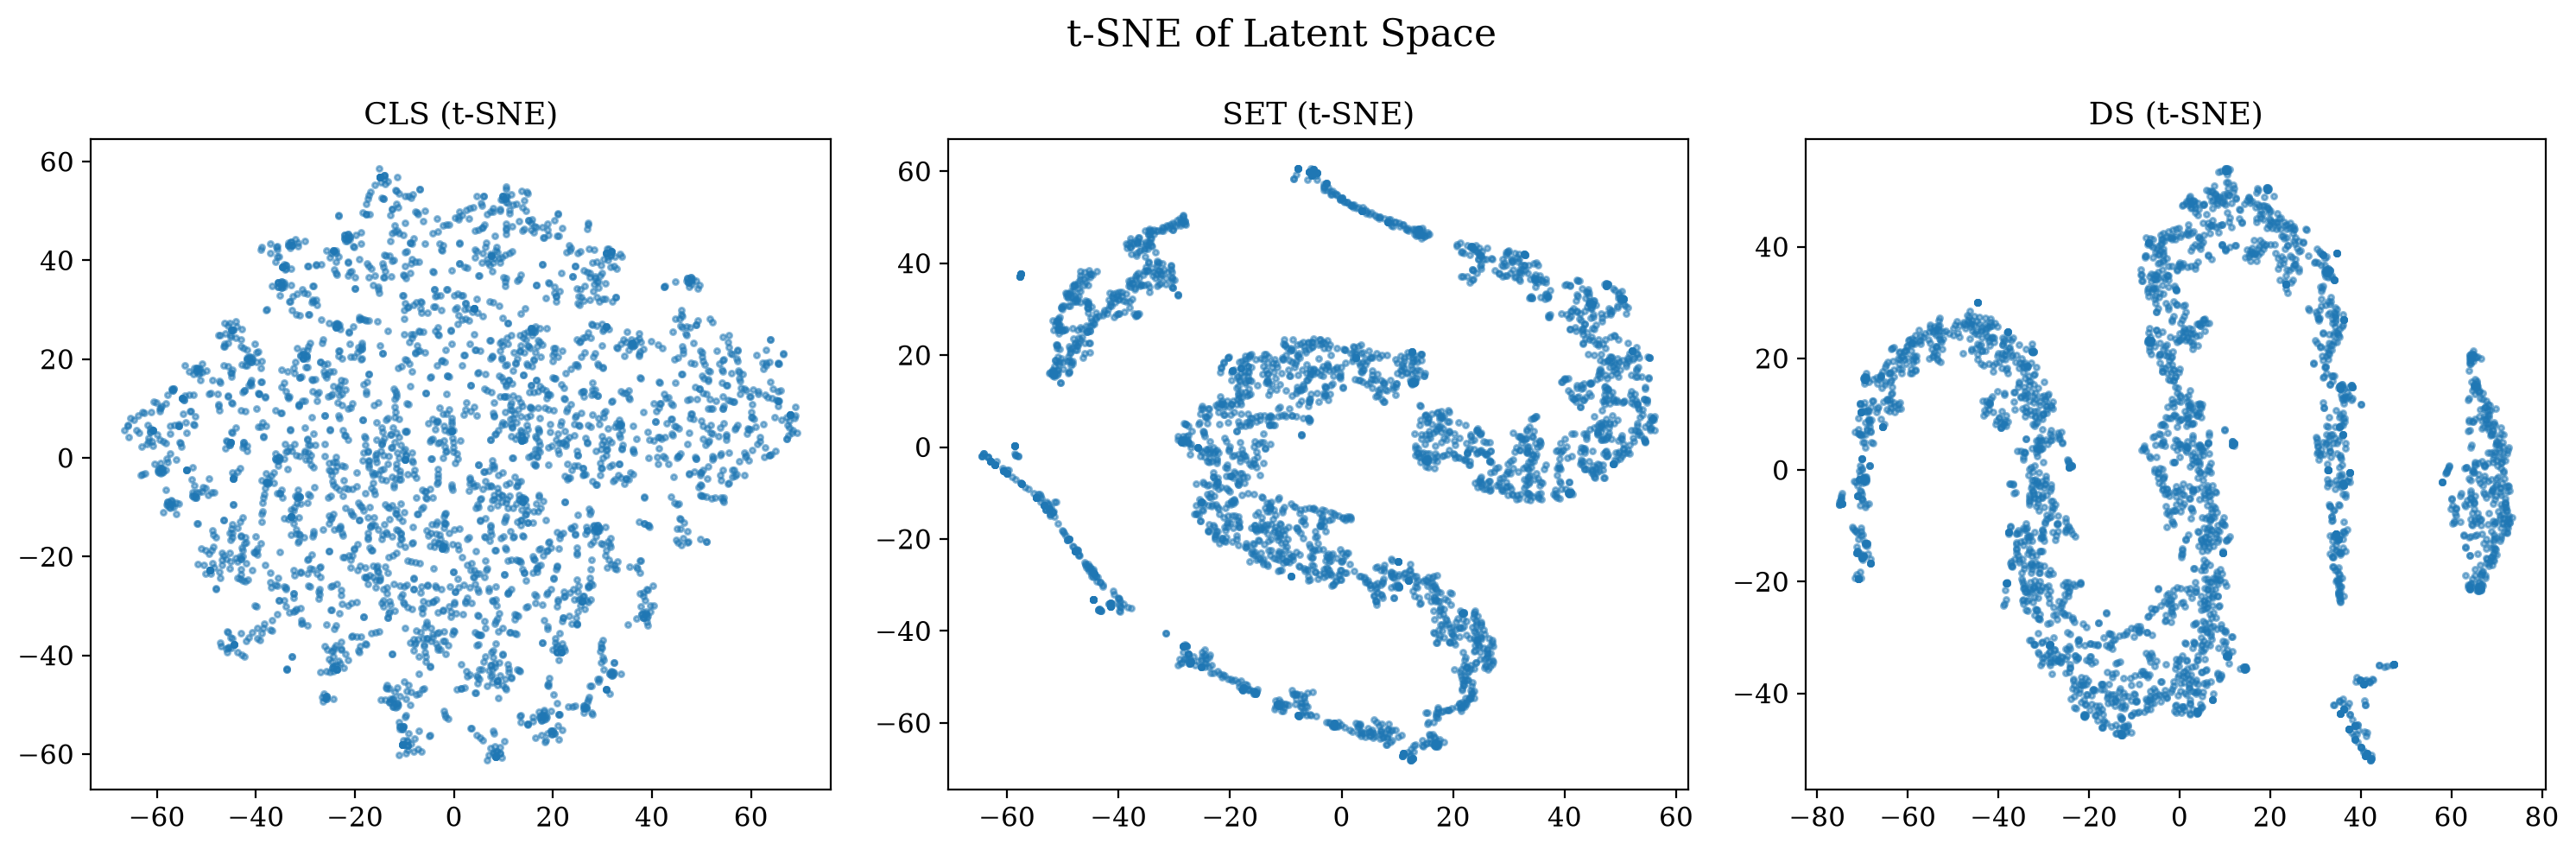

In [39]:
class RawTestDataset(Dataset):
    def __init__(self, h5_path):
        self.file = h5py.File(h5_path, 'r')
        self.ffp = self.file['cffp_256']
        self.auto = self.file['autocorr']
    def __len__(self): return self.ffp.shape[0]
    def __getitem__(self, idx):
        return torch.from_numpy(self.ffp[idx]).float(), torch.from_numpy(self.auto[idx]).float()
    def close(self): self.file.close()

test_ds = RawTestDataset('./data/DL/Deep_poly_datasets_Val.h5')
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

model_cls = load_pretrained_vae('CLS', './data/DL/models/CLS_VAE.pt', device)
model_set = load_pretrained_vae('SET', './data/DL/models/SET_VAE.pt', device)
model_ds = load_pretrained_vae('DS', './data/DL/models/DS_VAE.pt', device)

def get_latent_mu(model, loader):
    latents = []
    with torch.no_grad():
        for ffp, auto in loader:
            ffp, auto = ffp.to(device), auto.to(device)
            mu, _ = model.encode(ffp, auto)
            latents.append(mu.cpu().numpy())
    return np.concatenate(latents, axis=0)

z_cls = get_latent_mu(model_cls, test_loader)
z_set = get_latent_mu(model_set, test_loader)
z_ds = get_latent_mu(model_ds, test_loader)


def plot_pca(z_dict, title="PCA of Latent Space"):
    pca = PCA(n_components=2)
    fig, axes = plt.subplots(1, len(z_dict), figsize=(5*len(z_dict), 5))
    if len(z_dict) == 1: axes = [axes]
    for ax, (name, z) in zip(axes, z_dict.items()):
        if z is None: continue
        z_2d = pca.fit_transform(z)
        ax.scatter(z_2d[:,0], z_2d[:,1], s=1, alpha=0.5)
        ax.set_title(f'{name} (PCA)')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_pca({'CLS': z_cls, 'SET': z_set, 'DS': z_ds})

def plot_tsne(z_dict, title="t‑SNE of Latent Space", n_samples=3000):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    fig, axes = plt.subplots(1, len(z_dict), figsize=(5*len(z_dict), 5))
    if len(z_dict) == 1: axes = [axes]
    for ax, (name, z) in zip(axes, z_dict.items()):
        if z is None: continue
        idx = np.random.choice(len(z), min(n_samples, len(z)), replace=False)
        z_sub = z[idx]
        z_2d = tsne.fit_transform(z_sub)
        ax.scatter(z_2d[:,0], z_2d[:,1], s=5, alpha=0.5)
        ax.set_title(f'{name} (t‑SNE)')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_tsne({'CLS': z_cls, 'SET': z_set, 'DS': z_ds})

#### small set for adhesive prediction

Loaded 341 samples, labels shape: (341,)


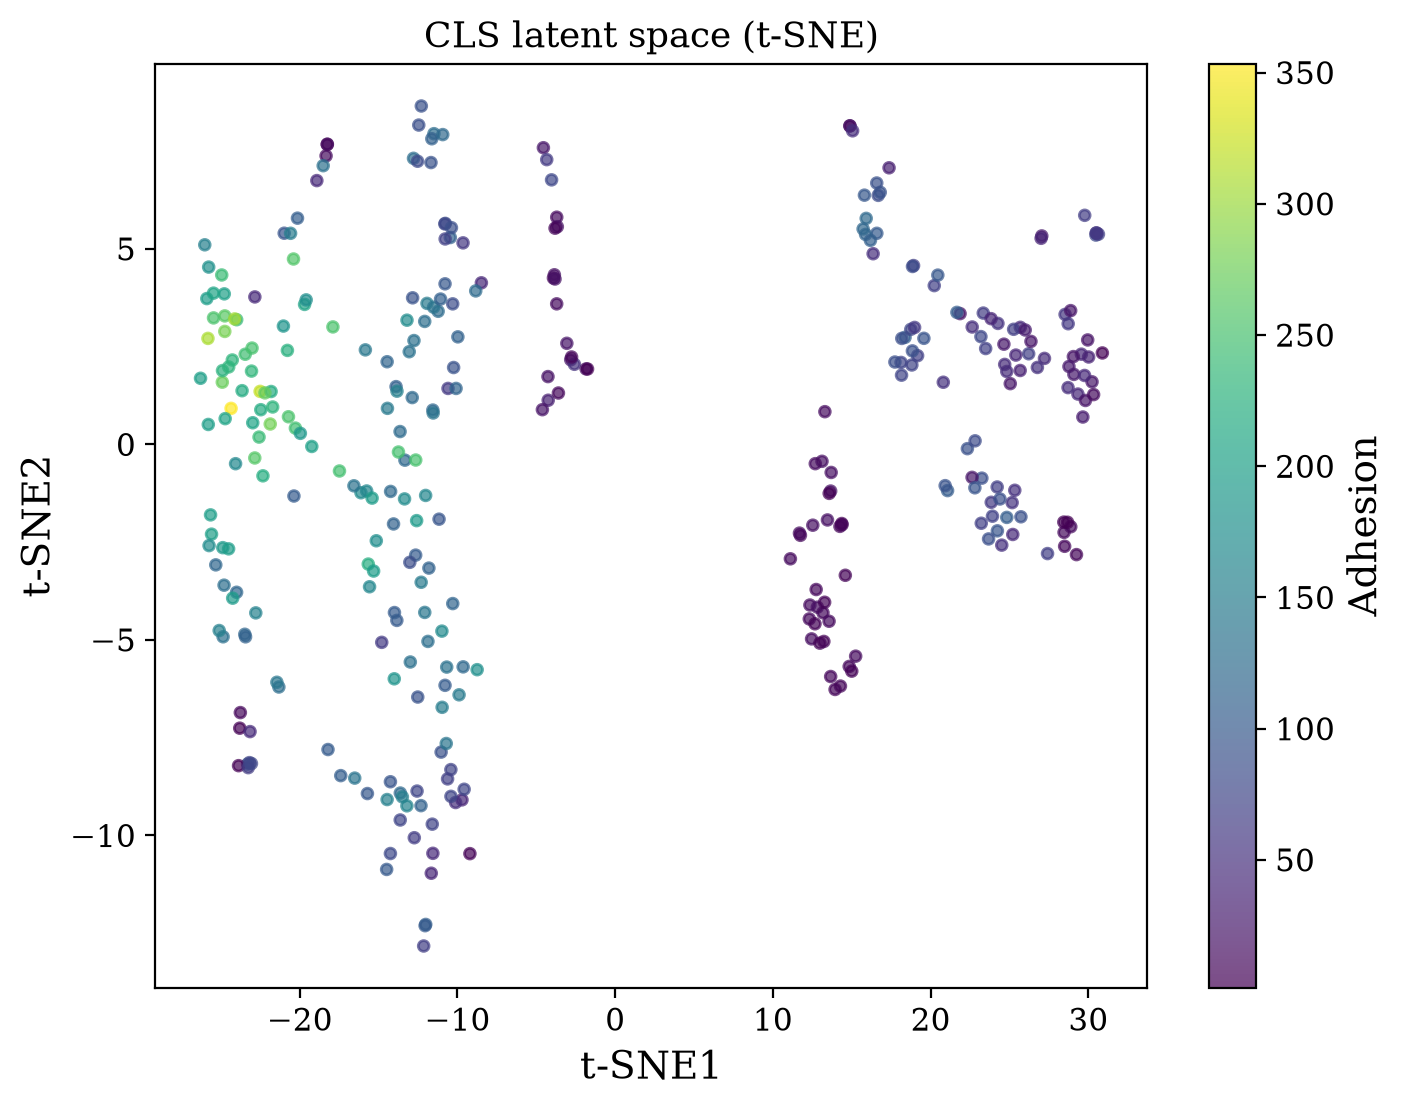

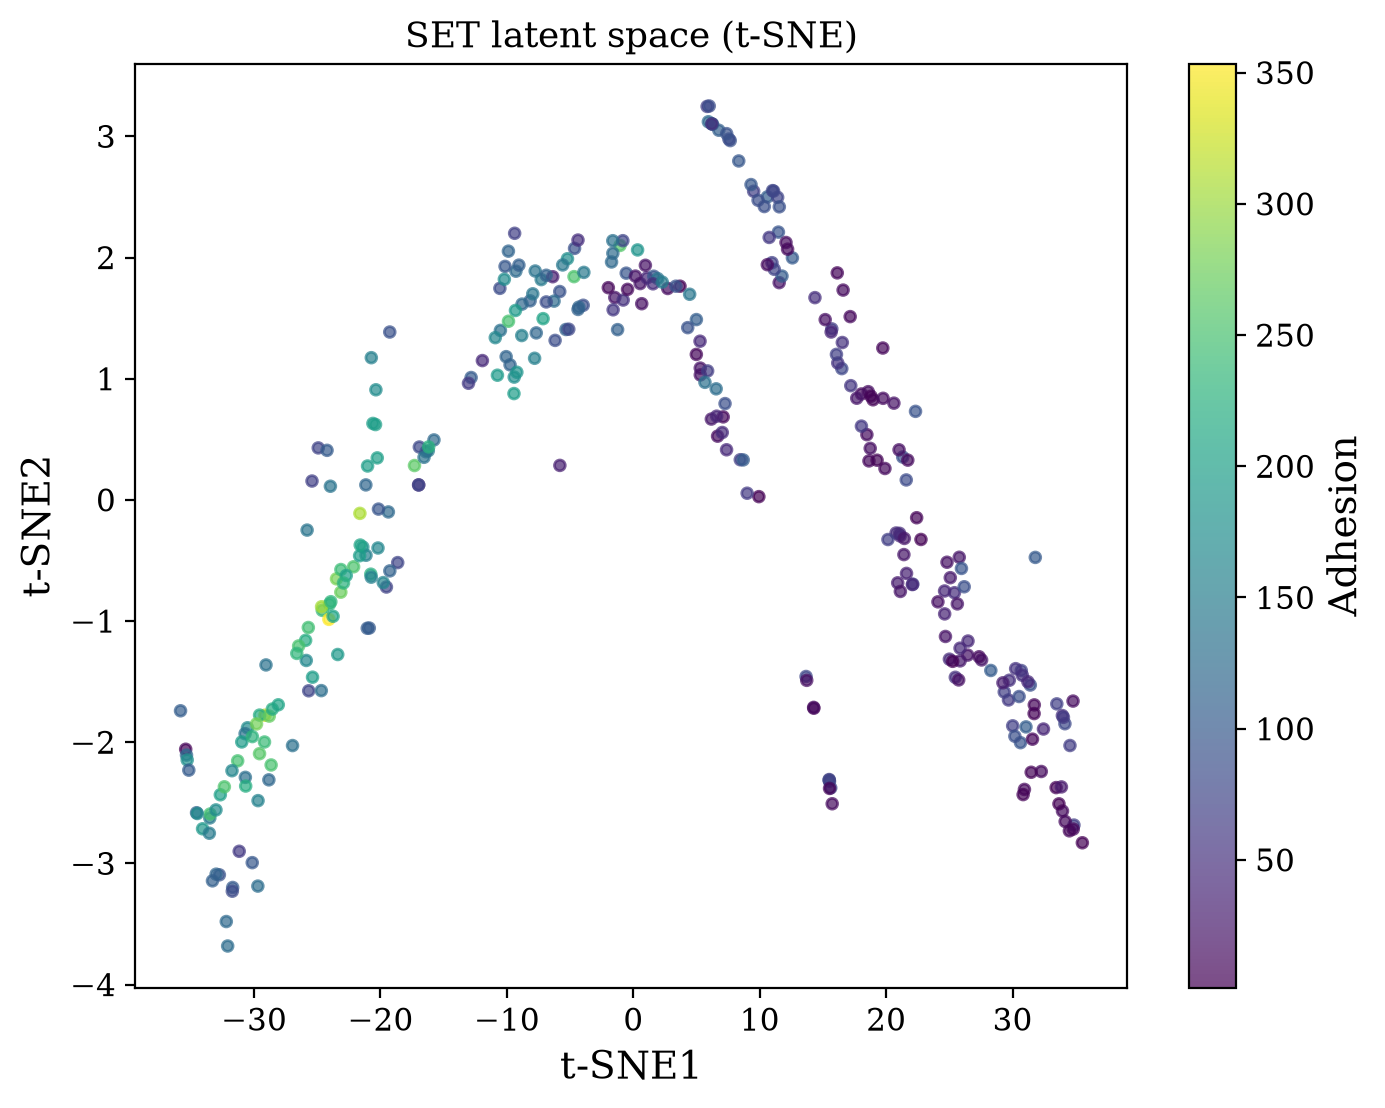

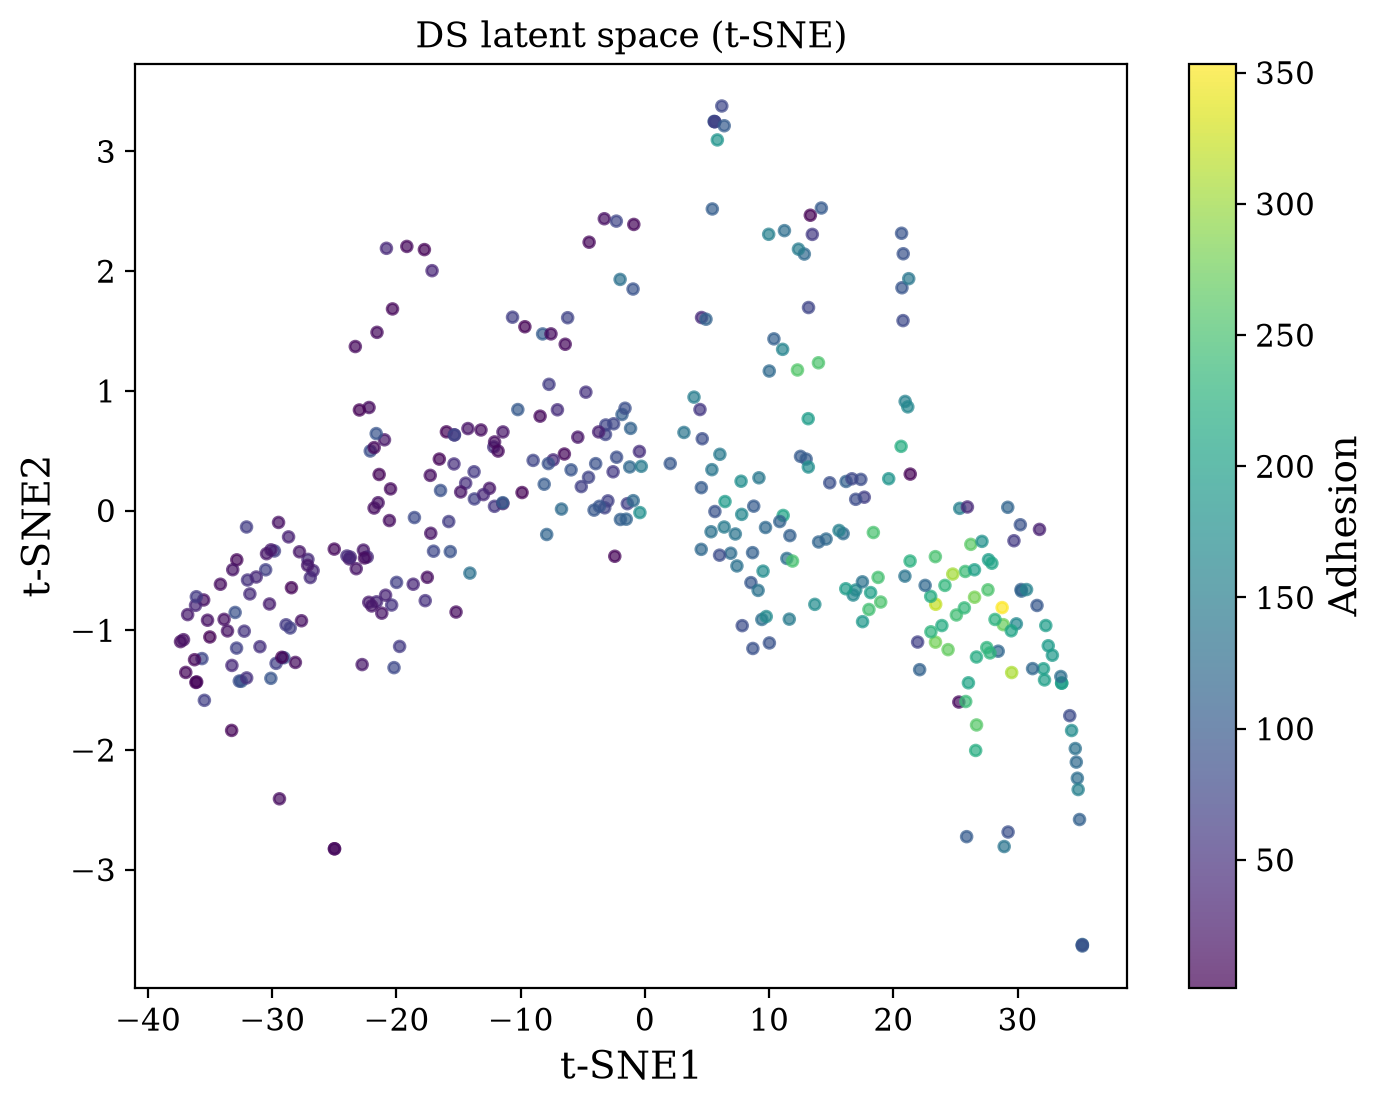

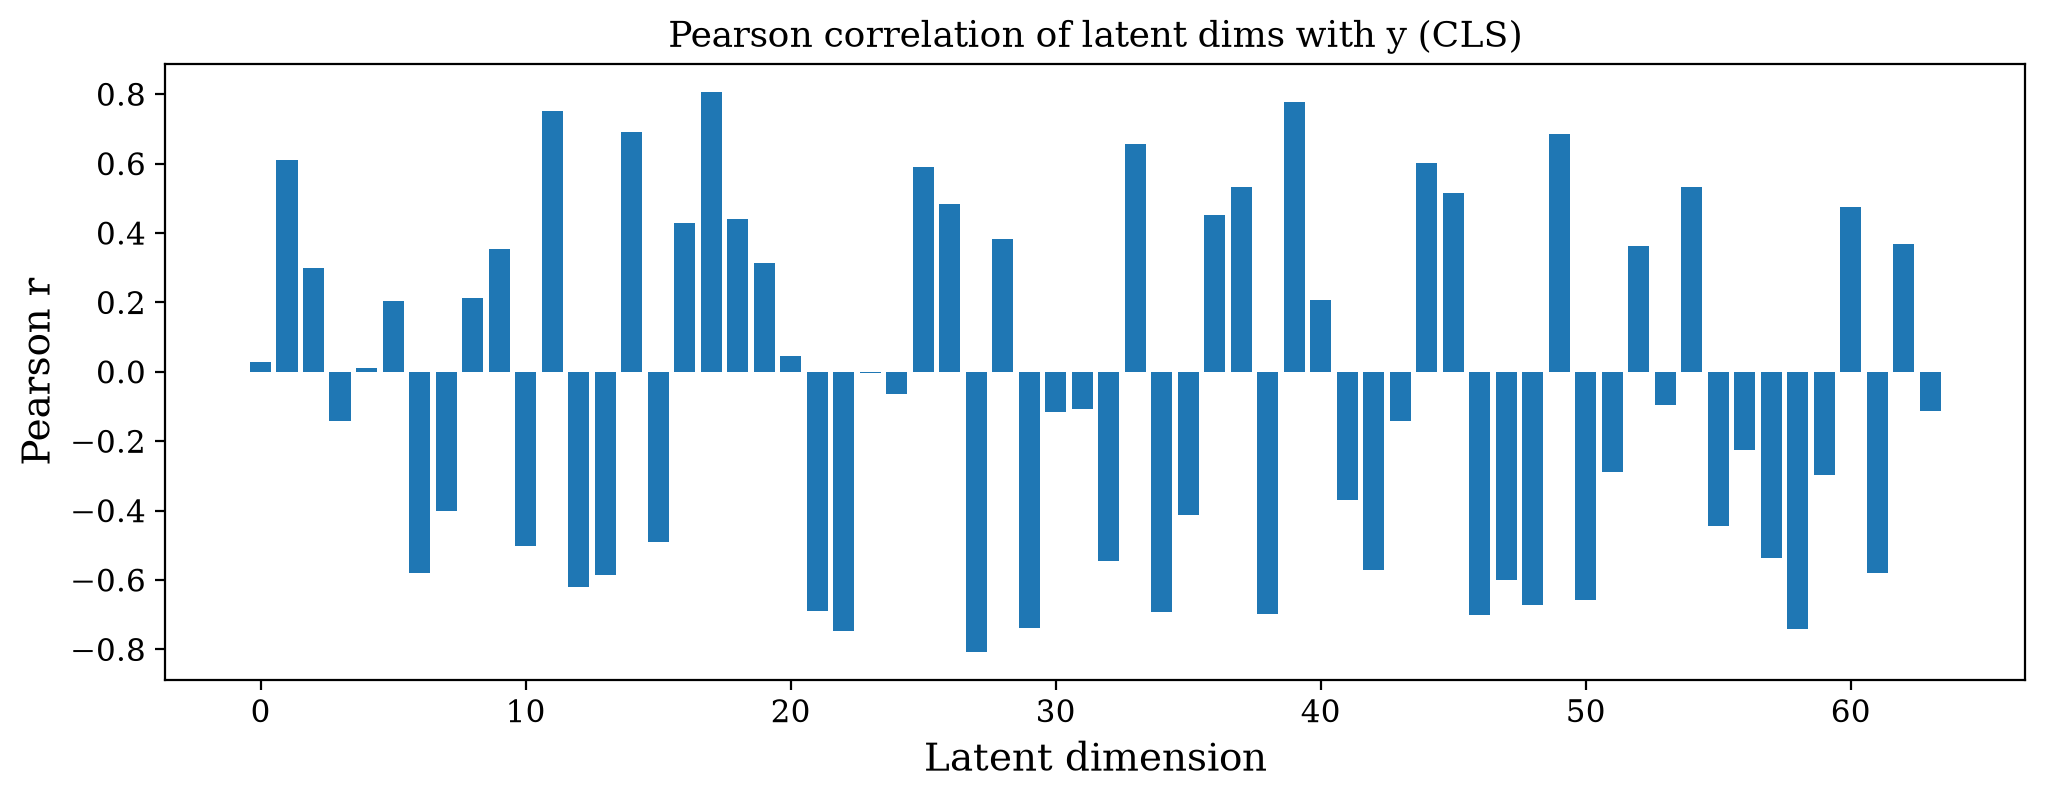

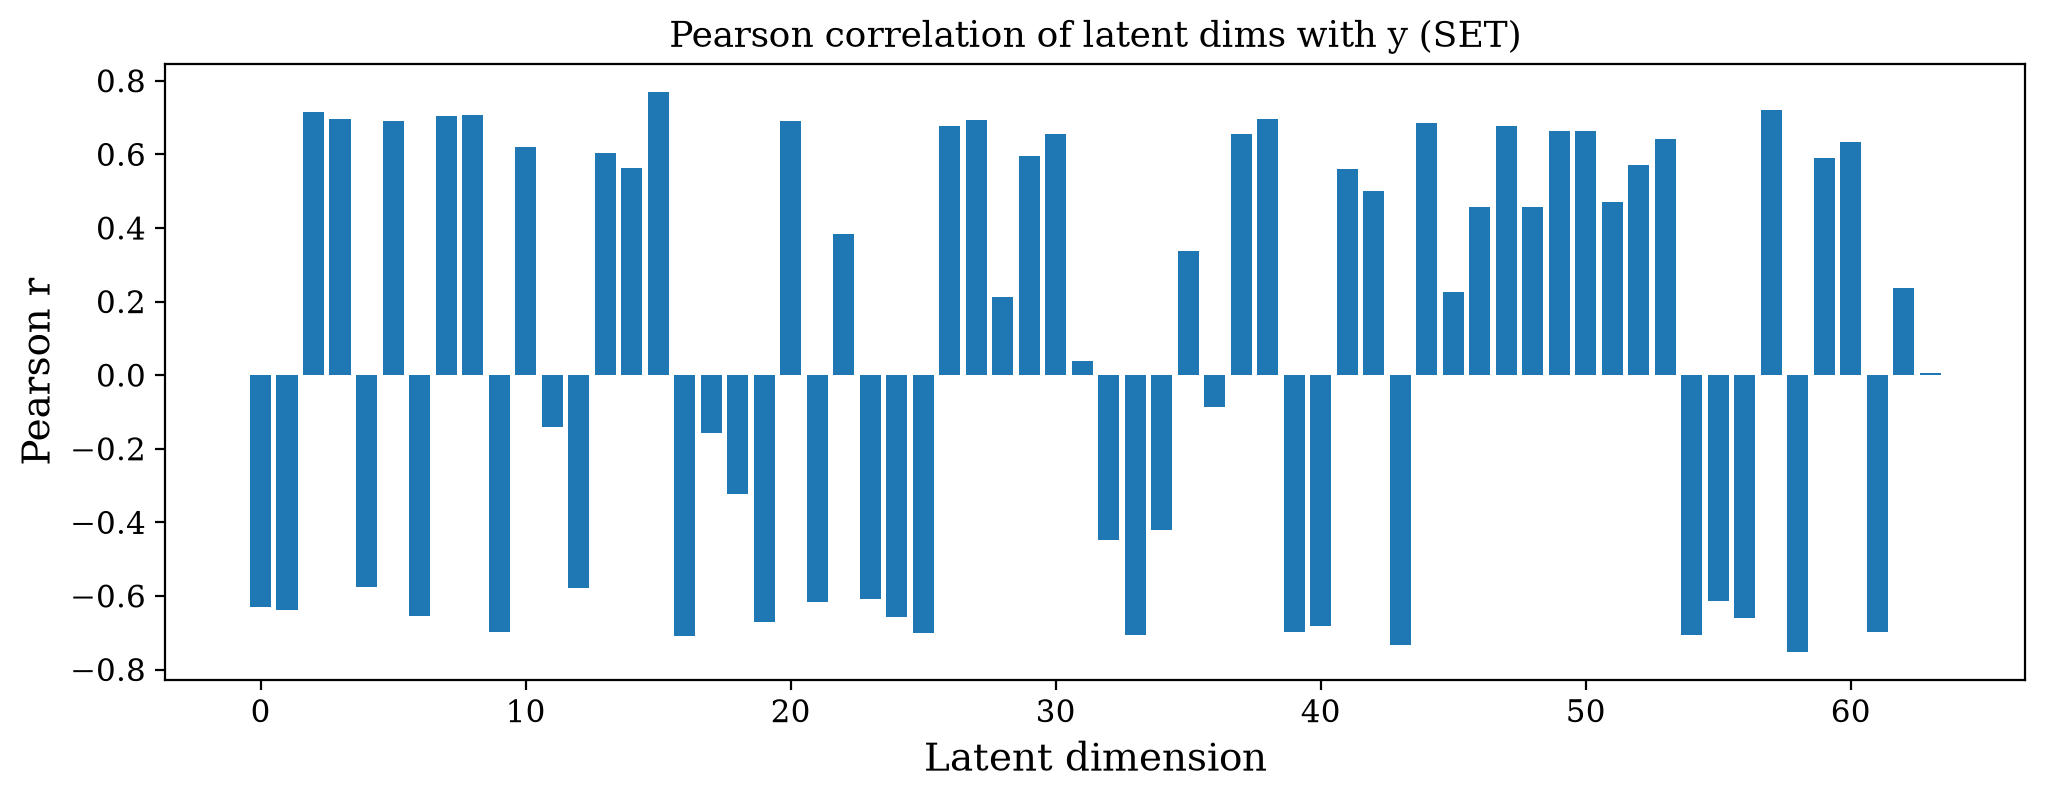

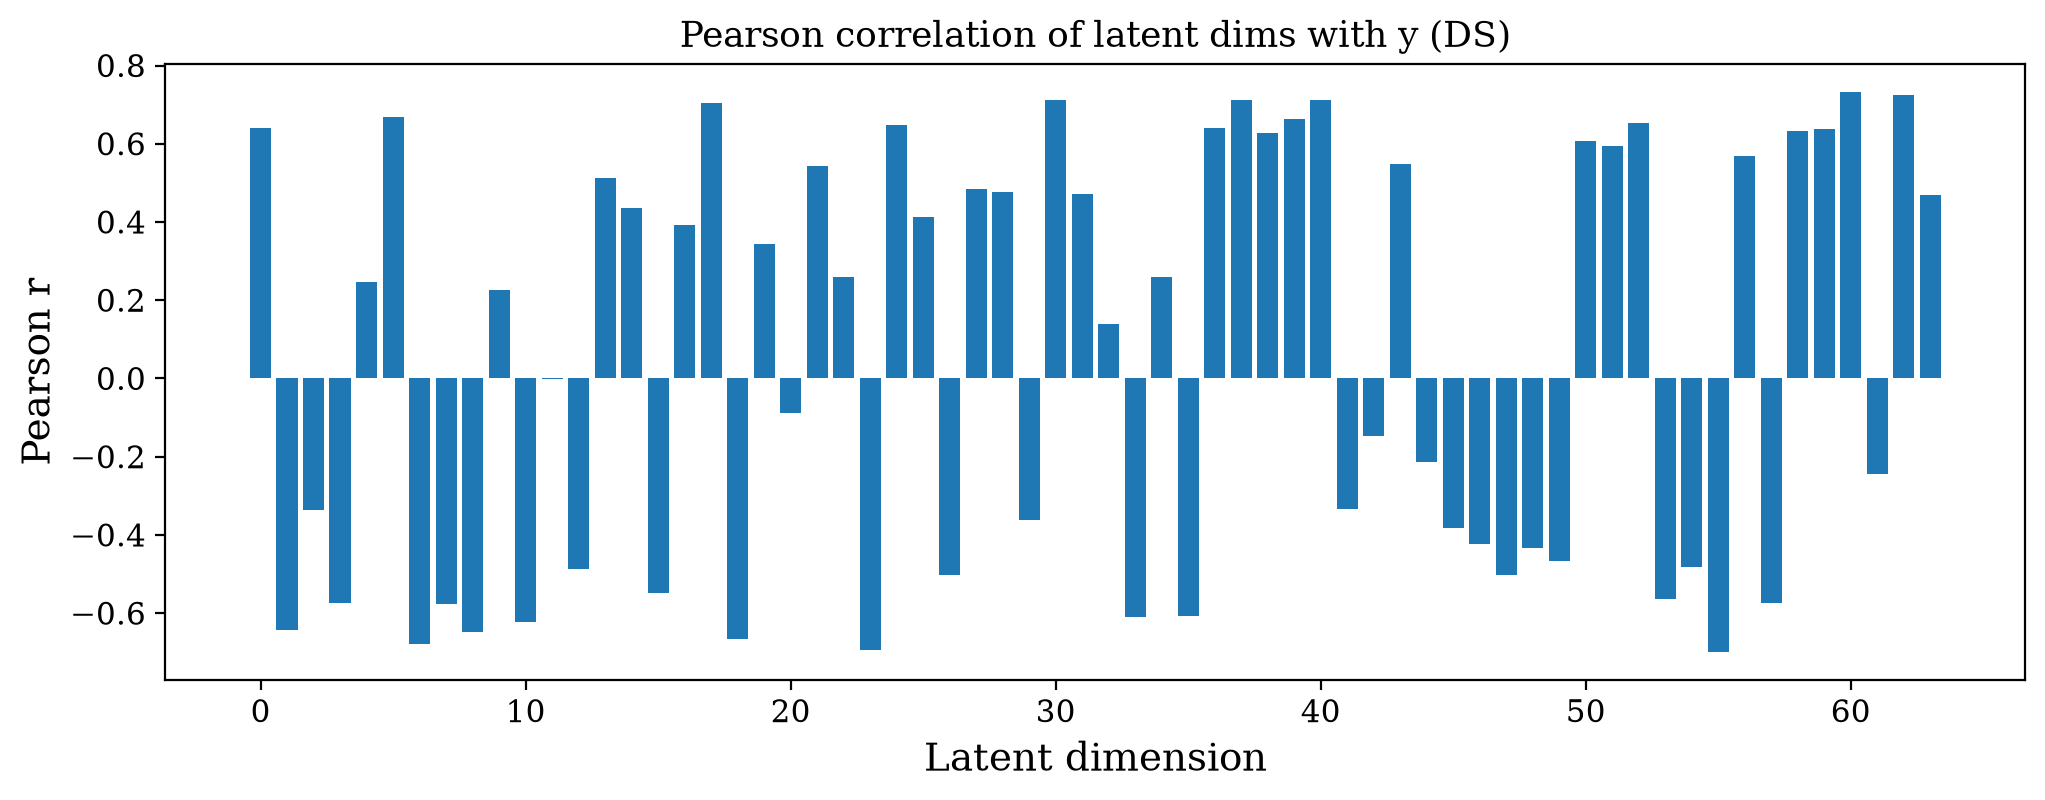


Cross‑validated R² on small set:
CLS Linear R²: 0.503 ± 0.176
CLS Ridge R²: 0.368 ± 0.394
SET Linear R²: -11455.978 ± 22592.705
SET Ridge R²: -0.862 ± 0.724
DS Linear R²: -325.568 ± 650.771
DS Ridge R²: -0.810 ± 0.769


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallDataset(Dataset):
    def __init__(self, h5_path):
        self.file = h5py.File(h5_path, 'r')
        self.ffp, self.auto = self.file['cffp_256'], self.file['autocorr']
        self.len = self.ffp.shape[0]
    def __len__(self): return self.len
    def __getitem__(self, idx):
        return torch.from_numpy(self.ffp[idx]).float(), torch.from_numpy(self.auto[idx]).float()
    def close(self): self.file.close()

small_ds = SmallDataset('./data/DL/small_poly_datasets.h5')
small_loader = DataLoader(small_ds, batch_size=32, shuffle=False, num_workers=0)

labels = adhesion.ravel() if adhesion.ndim > 1 else adhesion
print(f"Loaded {len(small_ds)} samples, labels shape: {labels.shape}")

models = {
    'CLS': load_pretrained_vae('CLS', './data/DL/models/CLS_VAE.pt', device),
    'SET': load_pretrained_vae('SET', './data/DL/models/SET_VAE.pt', device),
    'DS':  load_pretrained_vae('DS',  './data/DL/models/DS_VAE.pt',  device)
}

def get_latent_mu(model, loader):
    latents = []
    with torch.no_grad():
        for ffp, auto in loader:
            mu, _ = model.encode(ffp.to(device), auto.to(device))
            latents.append(mu.cpu().numpy())
    return np.concatenate(latents)

z_dict = {name: get_latent_mu(model, small_loader) for name, model in models.items()}

def plot_tsne_colored(z, lab, title, perplexity=30, sample_frac=1.0):
    if sample_frac < 1.0:
        idx = np.random.choice(len(z), int(len(z)*sample_frac), replace=False)
        z, lab = z[idx], lab[idx]
    z_2d = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(z)
    plt.figure(figsize=(8,6))
    sc = plt.scatter(z_2d[:,0], z_2d[:,1], c=lab, cmap='viridis', s=15, alpha=0.7)
    plt.colorbar(sc, label='Adhesion'); plt.title(title); plt.xlabel('t-SNE1'); plt.ylabel('t-SNE2'); plt.show()

for name, z in z_dict.items():
    plot_tsne_colored(z, labels, f'{name} latent space (t-SNE)')

def plot_correlations(z, lab, model_name):
    corrs = [pearsonr(z[:,i], lab)[0] for i in range(z.shape[1])]
    plt.figure(figsize=(12,4))
    plt.bar(range(len(corrs)), corrs)
    plt.title(f'Pearson correlation of latent dims with y ({model_name})')
    plt.xlabel('Latent dimension'); plt.ylabel('Pearson r'); plt.show()
    return corrs

for name, z in z_dict.items():
    plot_correlations(z, labels, name)

def evaluate_regression(z, lab, model_name):
    for reg, reg_name in [(LinearRegression(), 'Linear'), (Ridge(alpha=1.0), 'Ridge')]:
        scores = cross_val_score(reg, z, lab, cv=5, scoring='r2')
        print(f"{model_name} {reg_name} R²: {scores.mean():.3f} ± {scores.std():.3f}")

print("\nCross‑validated R² on small set:")
for name, z in z_dict.items():
    evaluate_regression(z, labels, name)

small_ds.close()

## MLP fast_test

In [41]:
class MLP(nn.Module):
    def __init__(self, latent_dim=64, hidden_dims=(128,64,32), dropout=0.2):
        super().__init__()
        layers = []
        in_dim = latent_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim,h), nn.LayerNorm(h), nn.Mish(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim,1))
        self.network = nn.Sequential(*layers)

    def forward(self, z):
        if z.ndim == 3: z = z.mean(dim=1)
        return self.network(z).squeeze(-1)

class FullPredictivePipeline(nn.Module):
    def __init__(self, pretrained_vae, latent_dim=64):
        super().__init__()
        self.vae = pretrained_vae
        self.vae.eval()
        for p in self.vae.parameters(): p.requires_grad = False
        self.predictor = MLP(latent_dim=latent_dim)

    def forward(self, ffp, auto):
        with torch.no_grad():
            mu, _ = self.vae.encode(ffp, auto)
        return self.predictor(mu)

In [42]:
class Dataset(Dataset):
    def __init__(self, h5_file, csv_file):
        with h5py.File(h5_file, "r") as f:
            self.ffp = f["cffp_256"][:].astype(np.float32)
            self.auto = f["autocorr"][:].astype(np.float32)

        df = pd.read_csv(csv_file)
        self.y = df["Glass (kPa)_max"].values.astype(np.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.ffp[idx]),
            torch.from_numpy(self.auto[idx]),
            torch.tensor(self.y[idx], dtype=torch.float32),
        )

In [43]:
dataset = Dataset(
    "./data/DL/small_poly_datasets.h5",
    "./data/df_341.csv",
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
)

In [44]:
predictor_train_config = {
    "batch_size": 32,
    "epochs": 500,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "patience": 20,
}

vae_checkpoints = {
    "CLS": "./data/DL/models/CLS_VAE.pt",
    "SET": "./data/DL/models/SET_VAE.pt",
    "DS":  "./data/DL/models/DS_VAE.pt",
}

In [45]:
def train_predictor(model, train_loader, val_loader, epochs, lr, weight_decay, patience, device, model_name):
    writer = SummaryWriter(log_dir=f"runs/{model_name}_MLP")
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.predictor.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    best_loss = float('inf'); no_improve = 0; history = {'train_loss':[], 'val_loss':[]}

    for epoch in range(1, epochs+1):
        model.train(); train_loss = 0.0
        for ffp, auto, y in train_loader:
            ffp, auto, y = ffp.to(device), auto.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(ffp, auto), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.predictor.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * y.size(0)
        train_loss /= len(train_loader.dataset)
        model.eval(); val_loss = 0.0
        with torch.no_grad():
            for ffp, auto, y in val_loader:
                ffp, auto, y = ffp.to(device), auto.to(device), y.to(device)
                val_loss += criterion(model(ffp, auto), y).item() * y.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar('Loss/Train', train_loss, epoch)
        writer.add_scalar('Loss/Validation', val_loss, epoch)
        writer.add_scalar('Learning_Rate', current_lr, epoch)

        if epoch % 5 == 0 or epoch == 1:
            for name, param in model.predictor.named_parameters():
                writer.add_histogram(f'Weights/{name}', param.data, epoch)
                if param.grad is not None:
                    writer.add_histogram(f'Gradients/{name}', param.grad.data, epoch)

        print(f"{model_name} | Epoch {epoch:03d} | Train {train_loss:.5f} | Val {val_loss:.5f} | LR {current_lr:.2e}")
        if val_loss < best_loss:
            best_loss = val_loss; no_improve = 0
            torch.save(model.predictor.state_dict(), f"./data/DL/models/{model_name}_MLP.pt")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping ({model_name})"); break

    writer.close()
    return history

In [46]:
histories = {}

for name, checkpoint in vae_checkpoints.items():

    print(f"\n{'='*60}")
    print(f"Training adhesion predictor using {name} encoder")
    print(f"{'='*60}")

    vae = load_pretrained_vae(
        model_type=name,
        checkpoint_path=checkpoint,
        device=device,
    )

    model = FullPredictivePipeline(
        pretrained_vae=vae,
        latent_dim=64,
    ).to(device)

    histories[name] = train_predictor(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=predictor_train_config["epochs"],
        lr=predictor_train_config["lr"],
        weight_decay=predictor_train_config["weight_decay"],
        patience=predictor_train_config["patience"],
        device=device,
        
        model_name=name,
    )

    del model
    del vae

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()


Training adhesion predictor using CLS encoder
CLS | Epoch 001 | Train 14038.77921 | Val 17760.40365 | LR 1.00e-03
CLS | Epoch 002 | Train 13850.42354 | Val 17644.42064 | LR 1.00e-03
CLS | Epoch 003 | Train 13763.41257 | Val 17537.67754 | LR 1.00e-03
CLS | Epoch 004 | Train 13657.43739 | Val 17426.88405 | LR 1.00e-03
CLS | Epoch 005 | Train 13572.38057 | Val 17312.36610 | LR 1.00e-03
CLS | Epoch 006 | Train 13466.73730 | Val 17191.25353 | LR 1.00e-03
CLS | Epoch 007 | Train 13360.94939 | Val 17064.22160 | LR 1.00e-03
CLS | Epoch 008 | Train 13248.26183 | Val 16933.28545 | LR 1.00e-03
CLS | Epoch 009 | Train 13121.49021 | Val 16798.74994 | LR 1.00e-03
CLS | Epoch 010 | Train 13034.11294 | Val 16662.90127 | LR 1.00e-03
CLS | Epoch 011 | Train 12896.14367 | Val 16523.15449 | LR 1.00e-03
CLS | Epoch 012 | Train 12777.48475 | Val 16380.93514 | LR 1.00e-03
CLS | Epoch 013 | Train 12645.52088 | Val 16237.42625 | LR 1.00e-03
CLS | Epoch 014 | Train 12559.43546 | Val 16092.37148 | LR 1.00e-03
C

In [47]:
print("\n" + "="*60)
print("Final predictor results")
print("="*60)

for name, hist in histories.items():

    best_val = min(hist["val_loss"])

    print(f"{name:>5} : Best validation MSE = {best_val:.6f}")


Final predictor results
  CLS : Best validation MSE = 977.746815
  SET : Best validation MSE = 2967.356639
   DS : Best validation MSE = 2036.625548


## MLP NLL

In [48]:
def read_sheet(path, cols, skip=1):
    d = pd.read_excel(path, sheet_name=0, header=None, skiprows=skip)
    d = d.iloc[:, :len(cols)]
    d.columns = cols
    return d

def parse_std(s):
    s = str(s).replace(',','.').strip()
    if '±' in s:
        m = re.search(r'([\d.]+)±([\d.]+)', s)
        return float(m.group(1)), float(m.group(2))
    try:
        v = float(s)
        return v, 0.07 * v
    except:
        return np.nan, np.nan

def process_data(data_dir='data'):
    cols6 = ['Round','ML','Rank','No.','ΦHEA','ΦBA','ΦCBEA','ΦATAC','ΦPEA','ΦAAm','Fa_max','Fa_ave','d','Q']
    df6 = read_sheet(f'{data_dir}/41586_2025_9269_MOESM6_ESM.xlsx', cols6)
    df6[['Round','ML','Rank']] = df6[['Round','ML','Rank']].ffill()
    df6 = df6[pd.to_numeric(df6['No.'], errors='coerce').notna()]
    df6 = df6[['ΦHEA','ΦBA','ΦCBEA','ΦATAC','ΦPEA','ΦAAm','Fa_max','Fa_ave']]

    cols5 = ['No.','ΦHEA','ΦBA','ΦCBEA','ΦATAC','ΦPEA','ΦAAm','Fa_max','Fa_ave','d','Q','G','Tanδ','k']
    df5 = read_sheet(f'{data_dir}/41586_2025_9269_MOESM5_ESM.xlsx', cols5)
    df5 = df5[['ΦHEA','ΦBA','ΦCBEA','ΦATAC','ΦPEA','ΦAAm','Fa_max','Fa_ave']]

    df = pd.concat([df6, df5], ignore_index=True)

    fracs = ['ΦHEA','ΦBA','ΦCBEA','ΦATAC','ΦPEA','ΦAAm']
    for c in fracs:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(',','.'), errors='coerce')

    df[['Fa_mean','Fa_std']] = df['Fa_ave'].apply(lambda x: pd.Series(parse_std(x)))

    mask = df['Fa_mean'].isna()
    df.loc[mask, 'Fa_mean'] = pd.to_numeric(df.loc[mask, 'Fa_max'].astype(str).str.replace(',','.'), errors='coerce') * 0.95
    df.loc[mask, 'Fa_std'] = df.loc[mask, 'Fa_mean'] * 0.07

    df = df.dropna(subset=['Fa_mean'])
    df = df[df['Fa_mean'] > 0]
    df = df.drop_duplicates(subset=fracs, keep='first')

    df['bin'] = pd.qcut(df['Fa_mean'], q=5, labels=['vlow','low','med','high','vhigh'])
    train_idx, val_idx = train_test_split(df.index, test_size=0.2, stratify=df['bin'], random_state=42)
    df['split'] = 'val'
    df.loc[train_idx, 'split'] = 'train'

    def augment(subset, n=30):
        x = np.repeat(subset[fracs].values, n, axis=0)
        m = np.repeat(subset['Fa_mean'].values, n)
        s = np.repeat(np.maximum(subset['Fa_std'].values, 0.01), n)
        y = np.maximum(np.random.normal(m, s), 0)
        return pd.DataFrame(x, columns=fracs).assign(Fa_target=y)

    final = pd.concat([
        augment(df[df['split']=='train']).assign(split='train'),
        augment(df[df['split']=='val']).assign(split='val')
    ], ignore_index=True)

    final.to_csv('./data/DL/final_data.csv', index=False)
    print(f"Unique compositions: {len(df)}")
    print(f"Total rows after augmentation: {len(final)}")
    return final

In [49]:
process_data()

Unique compositions: 347
Total rows after augmentation: 10410


,ΦHEA,ΦBA,ΦCBEA,ΦATAC,ΦPEA,ΦAAm,Fa_target,split
0,0.003000,0.521000,0.207000,0.10000,0.167,0.002000,87.956751,train
1,0.003000,0.521000,0.207000,0.10000,0.167,0.002000,84.620982,train
2,0.003000,0.521000,0.207000,0.10000,0.167,0.002000,90.414073,train
3,0.003000,0.521000,0.207000,0.10000,0.167,0.002000,86.164592,train
4,0.003000,0.521000,0.207000,0.10000,0.167,0.002000,90.623201,train
...,...,...,...,...,...,...,...,...
10405,0.144902,0.597204,0.108146,0.08747,0.000,0.062277,40.105968,val
10406,0.144902,0.597204,0.108146,0.08747,0.000,0.062277,43.049375,val
10407,0.144902,0.597204,0.108146,0.08747,0.000,0.062277,42.749488,val
10408,0.144902,0.597204,0.108146,0.08747,0.000,0.062277,44.999290,val


In [50]:
def get_latent_for_composition(fracs, vae, mon_indices, features_source, device):
    N_mon = 1000
    exact = fracs * N_mon
    counts = np.floor(exact).astype(np.int32)
    diff = N_mon - counts.sum()
    if diff > 0:
        rem_indices = np.argsort(exact % 1)[::-1]
        counts[rem_indices[:diff]] += 1
    global_chain = np.repeat(mon_indices, counts)
    np.random.shuffle(global_chain)
    auto_src = features_source['autocorr'][0]   # (num_monomers, autocorr_dim)
    cffp_src = features_source['cffp_256'][0]   # (num_monomers, cffp_dim)
    auto_chain = auto_src[global_chain]         # (N_mon, autocorr_dim)
    cffp_chain = cffp_src[global_chain]         # (N_mon, cffp_dim)
    
    with torch.no_grad():
        auto_t = torch.from_numpy(auto_chain).float().unsqueeze(0).to(device)
        cffp_t = torch.from_numpy(cffp_chain).float().unsqueeze(0).to(device)
        mu_z, _ = vae.encode(cffp_t, auto_t)
    return mu_z.squeeze(0).cpu().numpy()

In [51]:
def generate_latent_for_final_data(csv_path, vae, mon_indices, features_source, device, output_prefix='latent_final'):
    df = pd.read_csv(csv_path)
    mon_cols = ['ΦHEA','ΦBA','ΦCBEA','ΦATAC','ΦPEA','ΦAAm']
    comp = df[mon_cols].values.astype(np.float64)
    row_sums = comp.sum(axis=1, keepdims=True)
    comp = np.where(row_sums > 1.5, comp / 100.0, comp)
    row_sums = comp.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    comp /= row_sums
    
    unique_comps = np.unique(comp, axis=0)
    print(f": {len(unique_comps)}")
    
    z_list = []
    for fracs in unique_comps:
        z = get_latent_for_composition(fracs, vae, mon_indices, features_source, device)
        z_list.append(z)
    z_arr = np.array(z_list, dtype=np.float32)  # (N_unique, 64)
    
    np.save(f"./data/DL/npys/{output_prefix}_comps.npy", unique_comps)
    np.save(f"./data/DL/npys/{output_prefix}_z.npy", z_arr)
    print(f"./data/DL/npys/: {output_prefix}_comps.npy и {output_prefix}_z.npy")
    return unique_comps, z_arr

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for name, ckpt in [('CLS','./data/DL/models/CLS_VAE.pt'), ('SET','./data/DL/models/SET_VAE.pt'), ('DS','./data/DL/models/DS_VAE.pt')]:
    vae = load_pretrained_vae(name, ckpt, device)
    generate_latent_for_final_data(
        csv_path='./data/DL/final_data.csv',
        vae=vae,
        mon_indices=mon_indices,
        features_source=features_source,
        device=device,
        output_prefix=f'latent_final_{name}'
    )
    del vae
    torch.cuda.empty_cache()

: 347
./data/DL/npys/: latent_final_CLS_comps.npy и latent_final_CLS_z.npy
: 347
./data/DL/npys/: latent_final_SET_comps.npy и latent_final_SET_z.npy
: 347
./data/DL/npys/: latent_final_DS_comps.npy и latent_final_DS_z.npy


In [53]:
class LatentAdhesionDataset(Dataset):
    def __init__(self, csv_path, comps_npy, z_npy, mon_cols):
        comps_arr = np.load(comps_npy)
        z_arr = np.load(z_npy)
        self.comp_to_z = {tuple(comp): z for comp, z in zip(comps_arr, z_arr)}
        
        df = pd.read_csv(csv_path)
        self.mon_cols = mon_cols
        self.split = df['split'].values
        
        self.z_list = []
        self.y_list = []
        for _, row in df.iterrows():
            comp = tuple(row[mon_cols].values)
            comp_arr = np.array(comp, dtype=np.float64)
            row_sums = comp_arr.sum()
            if row_sums > 1.5:
                comp_arr = comp_arr / 100.0
            else:
                comp_arr = comp_arr / row_sums if row_sums > 0 else comp_arr
            key = tuple(comp_arr)
            z = self.comp_to_z.get(key)
            if z is None:
                raise KeyError(f" {key}")
            self.z_list.append(z)
            self.y_list.append(row['Fa_target'])
        
        self.z = np.array(self.z_list, dtype=np.float32)
        self.y = np.array(self.y_list, dtype=np.float32)
        print(f"В: {len(self.y)}")
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return (torch.from_numpy(self.z[idx]).float(),
                torch.tensor(self.y[idx], dtype=torch.float32))

In [54]:
class MLPNLL(nn.Module):
    def __init__(self, input_dim=64, hidden_dims=(512, 256, 128, 64), dropout=0.2):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims[:-1]:
            layers += [nn.Linear(in_dim, h), nn.LayerNorm(h), nn.Mish(), nn.Dropout(dropout)]
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.shared_last = nn.Sequential(
            nn.Linear(in_dim, hidden_dims[-1]),
            nn.LayerNorm(hidden_dims[-1]),
            nn.Mish(),
            nn.Dropout(dropout/2) 
        )
        self.mu_head = nn.Linear(hidden_dims[-1], 1)
        self.var_head = nn.Linear(hidden_dims[-1], 1)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        with torch.no_grad():
            self.mu_head.bias.data.fill_(100.0)          #  Fa ~100
            self.var_head.bias.data.fill_(np.log(100.0)) # σ ≈ 10, log_var ≈ 4.6
    
    def forward(self, z):
        if z.ndim == 3:
            z = z.mean(dim=1)
        h = self.backbone(z)
        h = self.shared_last(h)
        mu = self.mu_head(h).squeeze(-1)
        log_var = self.var_head(h).squeeze(-1)
        log_var = torch.clamp(log_var, min=-5, max=10)
        return mu, log_var

def gaussian_nll_loss(mu, log_var, target):
    var = torch.exp(log_var) + 1e-6
    loss = 0.5 * ((target - mu) ** 2 / var + log_var)
    return loss.mean()
    
def train_predictor(model, train_loader, val_loader, epochs, lr, weight_decay, patience, device, model_name):
    writer = SummaryWriter(log_dir=f"runs/{model_name}_MLPNLL")

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-6)

    best_loss = float('inf')
    best_mse = float('inf')
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_mse': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for z, y in train_loader:
            z, y = z.to(device), y.to(device)
            optimizer.zero_grad()
            mu, log_var = model(z)
            loss = gaussian_nll_loss(mu, log_var, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * y.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_mse = 0.0
        with torch.no_grad():
            for z, y in val_loader:
                z, y = z.to(device), y.to(device)
                mu, log_var = model(z)
                val_loss += gaussian_nll_loss(mu, log_var, y).item() * y.size(0)
                val_mse += torch.mean((mu - y) ** 2).item() * y.size(0)
        val_loss /= len(val_loader.dataset)
        val_mse /= len(val_loader.dataset)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mse'].append(val_mse)

        writer.add_scalar('Loss/Train', train_loss, epoch)
        writer.add_scalar('Loss/Validation', val_loss, epoch)
        writer.add_scalar('MSE/Validation', val_mse, epoch)
        writer.add_scalar('Learning_Rate', current_lr, epoch)

        if epoch % 5 == 0 or epoch == 1:
            for name, param in model.named_parameters():
                writer.add_histogram(f'Weights/{name}', param.data, epoch)
                if param.grad is not None:
                    writer.add_histogram(f'Gradients/{name}', param.grad.data, epoch)

        print(f"{model_name} | Epoch {epoch:03d} | Train {train_loss:.5f} | Val NLL {val_loss:.5f} | Val MSE {val_mse:.1f} | LR {current_lr:.2e}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_mse = val_mse
            no_improve = 0
            torch.save(model.state_dict(), f"./data/DL/models/{model_name}_MLPNLL.pt")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping ({model_name})")
                break

    writer.close()
    print(f"\nBest Val NLL: {best_loss:.5f}, Corresponding Val MSE: {best_mse:.1f}")
    return history, best_loss, best_mse

In [55]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mon_cols = ['ΦHEA','ΦBA','ΦCBEA','ΦATAC','ΦPEA','ΦAAm']

vae_checkpoints = {
    "CLS": ("./data/DL/models/CLS_VAE.pt", "./data/DL/npys/latent_final_CLS_comps.npy", "./data/DL/npys/latent_final_CLS_z.npy"),
    "SET": ("./data/DL/models/SET_VAE.pt", "./data/DL/npys/latent_final_SET_comps.npy", "./data/DL/npys/latent_final_SET_z.npy"),
    "DS":  ("./data/DL/models/DS_VAE.pt",  "./data/DL/npys/latent_final_DS_comps.npy",  "./data/DL/npys/latent_final_DS_z.npy"),
}

for name, (ckpt, comps_npy, z_npy) in vae_checkpoints.items():
    print(f"\n{'='*60}")
    print(f"Training adhesion predictor using {name} encoder")
    print(f"{'='*60}")
    
    dataset = LatentAdhesionDataset(
        csv_path='./data/DL/final_data.csv',
        comps_npy=comps_npy,
        z_npy=z_npy,
        mon_cols=mon_cols
    )
    
    train_indices = np.where(dataset.split == 'train')[0]
    val_indices = np.where(dataset.split == 'val')[0]
    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
    
    model = MLPNLL().to(device)
    history = train_predictor(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=500,
        lr=1e-4,
        weight_decay=1e-5,
        patience=40,
        device=device,
        model_name=name
    )
    
    del dataset, model, train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()


Training adhesion predictor using CLS encoder
В: 10410
CLS | Epoch 001 | Train 7.44831 | Val NLL 4.68192 | Val MSE 3928.0 | LR 1.00e-04
CLS | Epoch 002 | Train 4.66834 | Val NLL 4.61033 | Val MSE 3843.2 | LR 1.00e-04
CLS | Epoch 003 | Train 4.60456 | Val NLL 4.61887 | Val MSE 3775.7 | LR 1.00e-04
CLS | Epoch 004 | Train 4.58015 | Val NLL 4.57533 | Val MSE 3702.9 | LR 1.00e-04
CLS | Epoch 005 | Train 4.56064 | Val NLL 4.55769 | Val MSE 3638.6 | LR 1.00e-04
CLS | Epoch 006 | Train 4.53727 | Val NLL 4.54762 | Val MSE 3588.8 | LR 1.00e-04
CLS | Epoch 007 | Train 4.51779 | Val NLL 4.52205 | Val MSE 3495.4 | LR 1.00e-04
CLS | Epoch 008 | Train 4.50077 | Val NLL 4.52695 | Val MSE 3434.5 | LR 1.00e-04
CLS | Epoch 009 | Train 4.48003 | Val NLL 4.57386 | Val MSE 3359.3 | LR 1.00e-04
CLS | Epoch 010 | Train 4.47091 | Val NLL 4.56331 | Val MSE 3301.9 | LR 1.00e-04
CLS | Epoch 011 | Train 4.45235 | Val NLL 4.60262 | Val MSE 3216.1 | LR 1.00e-04
CLS | Epoch 012 | Train 4.43406 | Val NLL 4.62473 | V

## Optimizer on MLL fast

In [56]:
class HighScoreOptimizer:
    def __init__(self, predictor, emp_mean, emp_latents, lr=0.03, lambda_reg=0.0001):
        self.predictor = predictor.eval()
        self.emp_mean = torch.tensor(emp_mean, device=next(predictor.parameters()).device)
        self.emp_latents = torch.tensor(emp_latents, device=next(predictor.parameters()).device)
        self.lr = lr
        self.lambda_reg = lambda_reg
        self.n_init = len(emp_latents)

    def optimize(self, n_restarts=None, steps=1000, log_every=20, save_all_trajectories=False, tb_writer=None, tag='opt'):
        if n_restarts is None:
            n_restarts = self.n_init
        device = next(self.predictor.parameters()).device

        best_score = -float('inf')
        best_z = None
        best_traj = None
        best_y_hist = None
        best_reg_hist = None
        all_restarts = []

        for restart in range(n_restarts):
            base = self.emp_latents[np.random.randint(0, self.n_init)]
            noise = torch.randn(self.emp_latents.shape[1], device=device) * 0.05 * self.emp_mean.std()
            z = (base + noise).clone().requires_grad_(True)
            opt = optim.Adam([z], lr=self.lr)

            traj_z = []
            traj_y = []
            traj_reg = []

            for step in range(steps):
                opt.zero_grad()
                y = self.predictor(z.unsqueeze(0)).squeeze()
                lam = self.lambda_reg * max(0, 1 - step / steps)
                reg = lam * (z - self.emp_mean).pow(2).mean()
                loss = -y + reg
                loss.backward()
                opt.step()

                if step % log_every == 0 or step == steps - 1:
                    traj_z.append(z.detach().cpu().numpy().copy())
                    traj_y.append(y.item())
                    traj_reg.append(reg.item())

            with torch.no_grad():
                final_score = self.predictor(z.unsqueeze(0)).item()

            restart_info = {
                'z_final': z.detach().cpu().numpy().copy(),
                'y_final': final_score,
                'trajectory': np.array(traj_z),
                'y_history': np.array(traj_y),
                'reg_history': np.array(traj_reg)
            }
            all_restarts.append(restart_info)

            if final_score > best_score:
                best_score = final_score
                best_z = z.detach().clone()
                best_traj = np.array(traj_z)
                best_y_hist = np.array(traj_y)
                best_reg_hist = np.array(traj_reg)

        if tb_writer is not None and best_traj is not None:
            tb_writer.add_scalar(f'{tag}/best_score', best_score, 0)
            for step, (y_val, reg_val) in enumerate(zip(best_y_hist, best_reg_hist)):
                tb_writer.add_scalar(f'{tag}/y_best', y_val, step * log_every)
                tb_writer.add_scalar(f'{tag}/reg_best', reg_val, step * log_every)
            tb_writer.add_histogram(f'{tag}/latent_best', best_z.cpu(), 0)

        return best_z, best_score, best_traj, best_y_hist, best_reg_hist, all_restarts

In [57]:
def run_optimization_pipeline(
    model_type,
    vae_checkpoint,
    predictor_checkpoint,
    db_path,
    valid_df,
    device=None,
    n_restarts=700,
    steps=1000,
    lr=0.03,
    lambda_reg=0.0001,
    n_neighbors=50,
    tolerance=0.05,
    log_every=20,
    save_restarts=True,
    make_animation=False
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    writer = SummaryWriter(log_dir=f"runs/{model_type}_optimizer_MLP")

    vae = load_pretrained_vae(model_type, vae_checkpoint, device)
    predictor = MLP(latent_dim=64).to(device)
    predictor.load_state_dict(torch.load(predictor_checkpoint, map_location=device))
    predictor.eval()

    emp_mean, real_latents = get_real_latents(vae)

    del vae
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    optimizer = HighScoreOptimizer(predictor, emp_mean, real_latents, lr, lambda_reg)
    best_z, best_score, best_traj, best_y_hist, best_reg_hist, all_restarts = optimizer.optimize(
        n_restarts=n_restarts, steps=steps, log_every=log_every,
        save_all_trajectories=save_restarts, tb_writer=writer, tag=model_type
    )

    print(f"Optimal Y: {best_score:.4f}")

    with h5py.File(db_path, 'r') as f:
        if 'latent' in f:
            latents = f['latent'][:]
        elif 'mu' in f:
            latents = f['mu'][:]
        else:
            raise KeyError("No latent dataset found in HDF5 file (expected 'latent' or 'mu')")
        
        fracs = f['fractions'][:]

    z_opt_np = best_z.cpu().numpy().reshape(1, -1)
    dists = cdist(z_opt_np, latents).flatten()
    neighbor_indices = np.argsort(dists)[:n_neighbors]

    neighbor_mu = torch.tensor(latents[neighbor_indices], device=device)
    with torch.no_grad():
        y_neighbors = predictor(neighbor_mu).cpu().numpy().flatten()

    best_local_idx = np.argmax(y_neighbors)
    best_frac = fracs[neighbor_indices[best_local_idx]]   # вектор долей
    best_y = y_neighbors[best_local_idx]

    mask = best_frac > 0
    best_mono_indices = np.where(mask)[0]
    best_frac_values = best_frac[mask]

    rel_diff = abs(best_y - best_score) / (abs(best_score) + 1e-8)
    writer.add_scalar('final/best_y', best_y, 0)
    writer.add_scalar('final/deviation', rel_diff, 0)
    writer.add_histogram('final/latent_best', best_z.cpu(), 0)

    mon_names = valid_df['name'].tolist()
    result = {
        'z_opt': z_opt_np.flatten(),
        'y_opt': best_score,
        'best_y': best_y,
        'deviation': rel_diff,
        'monomer_indices': best_mono_indices.tolist(),
        'fractions': best_frac_values.tolist(),
        'monomer_names': [mon_names[i] for i in best_mono_indices],
        'within_tolerance': rel_diff <= tolerance
    }

    if save_restarts:
        endpoints = np.array([r['z_final'] for r in all_restarts])
        y_vals = np.array([r['y_final'] for r in all_restarts])
        if endpoints.shape[1] > 2:
            pca = PCA(n_components=2)
            endpoints_2d = pca.fit_transform(endpoints)
        else:
            endpoints_2d = endpoints
        plt.figure(figsize=(10,8))
        sc = plt.scatter(endpoints_2d[:,0], endpoints_2d[:,1], c=y_vals, cmap='viridis', s=60, alpha=0.7)
        plt.colorbar(sc, label='Final Y')
        plt.title(f'{model_type} restarts endpoints')
        plt.savefig(f'./data/img/{model_type}_restarts.png', dpi=150)
        plt.close()

        if best_traj is not None and len(best_traj) > 1:
            if best_traj.shape[1] > 2:
                pca2 = PCA(n_components=2)
                traj_2d = pca2.fit_transform(best_traj)
            else:
                traj_2d = best_traj
            fig, ax = plt.subplots(figsize=(10,8))
            scatter = ax.scatter(traj_2d[:,0], traj_2d[:,1], c=best_y_hist, cmap='viridis', s=40, alpha=0.8)
            ax.plot(traj_2d[:,0], traj_2d[:,1], 'gray', alpha=0.5, linestyle='--')
            ax.scatter(traj_2d[0,0], traj_2d[0,1], color='red', marker='o', s=120, label='start')
            ax.scatter(traj_2d[-1,0], traj_2d[-1,1], color='blue', marker='*', s=200, label='end')
            ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
            ax.legend()
            plt.colorbar(scatter, label='Y')
            plt.title(f'{model_type} best trajectory')
            plt.savefig(f'./data/img/{model_type}_trajectory_2d.png', dpi=150)
            plt.close()

            if make_animation and len(traj_2d) > 10:
                fig, ax = plt.subplots(figsize=(8,6))
                ax.set_xlim(traj_2d[:,0].min()-0.5, traj_2d[:,0].max()+0.5)
                ax.set_ylim(traj_2d[:,1].min()-0.5, traj_2d[:,1].max()+0.5)
                line, = ax.plot([], [], 'b-', alpha=0.3)
                point, = ax.plot([], [], 'ro', markersize=8)
                def init(): line.set_data([], []); point.set_data([], []); return line, point
                def animate(i):
                    line.set_data(traj_2d[:i+1,0], traj_2d[:i+1,1])
                    point.set_data([traj_2d[i,0]], [traj_2d[i,1]])
                    return line, point
                ani = animation.FuncAnimation(fig, animate, frames=len(traj_2d), init_func=init, interval=100, blit=True, repeat=False)
                ani.save(f'./data/img/{model_type}_trajectory.gif', writer='pillow', fps=10)
                plt.close()

    writer.close()
    return result

In [58]:
def get_real_latents(vae, h5_path='./data/DL/small_poly_datasets.h5', device=None, batch_size=64):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vae.eval()
    
    all_mu = []
    with h5py.File(h5_path, 'r') as f:
        total = f['cffp_256'].shape[0]
        for start in range(0, total, batch_size):
            end = min(start + batch_size, total)
            ffp = torch.from_numpy(f['cffp_256'][start:end]).float().to(device)
            auto = torch.from_numpy(f['autocorr'][start:end]).float().to(device)
            with torch.no_grad():
                mu, _ = vae.encode(ffp, auto)
            all_mu.append(mu.cpu().numpy())
            del ffp, auto, mu
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    mu_all = np.concatenate(all_mu, axis=0)
    return mu_all.mean(axis=0), mu_all

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = ['CLS', 'SET', 'DS']
all_results = {}

for model in models:
    print(f"\n{'='*60}\nProcessing {model}\n{'='*60}")
    
    result = run_optimization_pipeline(
        model_type=model,
        vae_checkpoint=f'./data/DL/models/{model}_VAE.pt',
        predictor_checkpoint=f'./data/DL/models/{model}_MLP.pt',
        db_path=f'./data/DL/latent_db_{model}.h5',
        valid_df=valid_df,
        device=device,
        n_restarts=700,
        steps=1000,
        lr=0.03,
        lambda_reg=0.0001,
        n_neighbors=50,
        tolerance=0.05,
        log_every=20,
        save_restarts=True,
        make_animation=True                   #  GIF 
    )
    
    all_results[model] = result
    
    print(f"Best composition for {model}:")
    print(f"  Y = {result['best_y']:.4f} (opt: {result['y_opt']:.4f}, deviation: {result['deviation']*100:.2f}%)")
    print(f"  Monomers: {', '.join(result['monomer_names'])}")
    print(f"  Fractions: {[round(f,4) for f in result['fractions']]}")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

df_results = pd.DataFrame([{
    'model': m,
    'best_y': r['best_y'],
    'y_opt': r['y_opt'],
    'deviation_%': r['deviation'] * 100,
    'within_tolerance': r['within_tolerance'],
    'monomers': ' + '.join(r['monomer_names']),
    'fractions': str([round(f,4) for f in r['fractions']])
} for m, r in all_results.items()])

df_results.to_csv('./data/DL/model_comparison_MLP.csv', index=False)

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(df_results.to_string(index=False))

best_model = df_results.loc[df_results['best_y'].idxmax()]
print(f"\nBest model: {best_model['model']} with Y = {best_model['best_y']:.4f}")


Processing CLS
Optimal Y: 204.1201
Best composition for CLS:
  Y = 203.8772 (opt: 204.1201, deviation: 0.12%)
  Monomers: n-Butyl acrylate, [2-(Acryloyloxy)ethyl]triethylammonium chloride, Phenyl acrylate, 2-(4-Chlorophenoxy)ethyl acrylate, 2-(4-Nitrophenoxy)ethyl acrylate
  Fractions: [0.8036, 0.0978, 0.0643, 0.014, 0.0203]

Processing SET
Optimal Y: 139.5866
Best composition for SET:
  Y = 139.2658 (opt: 139.5866, deviation: 0.23%)
  Monomers: Poly(ethylene glycol) methyl ether acrylate, Methacrylic acid, Vinylbenzyl trimethylammonium chloride, N-tert-Butylacrylamide
  Fractions: [0.0004, 0.1357, 0.0752, 0.7887]

Processing DS
Optimal Y: 165.4148
Best composition for DS:
  Y = 165.3501 (opt: 165.4148, deviation: 0.04%)
  Monomers: [2-(Acryloyloxy)ethyl]dimethylbenzylammonium chloride, [2-(Acryloyloxy)ethyl]triethylammonium chloride
  Fractions: [0.439, 0.561]

MODEL COMPARISON
model     best_y      y_opt  deviation_%  within_tolerance                                                 

## Optimizer on MLL NLL

In [60]:
class HighScoreOptimizer:
    def __init__(self, predictor, emp_mean, emp_latents, lr=0.03, lambda_reg=0.0001, sigma_multiplier=1.64):
        self.predictor = predictor.eval()
        self.emp_mean = torch.tensor(emp_mean, device=next(predictor.parameters()).device)
        self.emp_latents = torch.tensor(emp_latents, device=next(predictor.parameters()).device)
        self.lr = lr
        self.lambda_reg = lambda_reg
        self.sigma_multiplier = sigma_multiplier
        self.n_init = len(emp_latents)

    def optimize(self, n_restarts=None, steps=1000, log_every=20, save_all_trajectories=False, tb_writer=None, tag='opt'):
        if n_restarts is None:
            n_restarts = self.n_init
        device = next(self.predictor.parameters()).device

        best_score = -float('inf')
        best_z = None
        best_traj = None
        best_y_hist = None
        best_reg_hist = None
        all_restarts = []

        for restart in range(n_restarts):
            base = self.emp_latents[np.random.randint(0, self.n_init)]
            noise = torch.randn(self.emp_latents.shape[1], device=device) * 0.05 * self.emp_mean.std()
            z = (base + noise).clone().requires_grad_(True)
            opt = optim.Adam([z], lr=self.lr)

            traj_z = []
            traj_score = []
            traj_reg = []

            for step in range(steps):
                opt.zero_grad()
                mu, log_var = self.predictor(z.unsqueeze(0))
                sigma = torch.exp(0.5 * log_var)  
                y = mu + self.sigma_multiplier * sigma
                y = y.squeeze()
                reg = self.lambda_reg * (
                    (z - self.emp_mean).pow(2).mean() + 
                    0.5 * torch.exp(log_var).mean()
                )
                loss = -y + reg
                loss.backward()
                opt.step()

                if step % log_every == 0 or step == steps - 1:
                    traj_z.append(z.detach().cpu().numpy().copy())
                    traj_score.append(y.item())
                    traj_reg.append(reg.item())

            with torch.no_grad():
                mu_final, log_var_final = self.predictor(z.unsqueeze(0))
                sigma_final = torch.exp(0.5 * log_var_final)
                final_score = (mu_final + self.sigma_multiplier * sigma_final).item()

            restart_info = {
                'z_final': z.detach().cpu().numpy().copy(),
                'y_final': final_score,
                'trajectory': np.array(traj_z),
                'score_history': np.array(traj_score),
                'reg_history': np.array(traj_reg)
            }
            all_restarts.append(restart_info)

            if final_score > best_score:
                best_score = final_score
                best_z = z.detach().clone()
                best_traj = np.array(traj_z)
                best_y_hist = np.array(traj_score)
                best_reg_hist = np.array(traj_reg)

        if tb_writer is not None and best_traj is not None:
            tb_writer.add_scalar(f'{tag}/best_score', best_score, 0)
            for step, (y_val, reg_val) in enumerate(zip(best_y_hist, best_reg_hist)):
                tb_writer.add_scalar(f'{tag}/score_best', y_val, step * log_every)
                tb_writer.add_scalar(f'{tag}/reg_best', reg_val, step * log_every)
            tb_writer.add_histogram(f'{tag}/latent_best', best_z.cpu(), 0)

        return best_z, best_score, best_traj, best_y_hist, best_reg_hist, all_restarts

In [61]:
def run_optimization_pipeline(
    model_type,
    vae_checkpoint,
    predictor_checkpoint,
    db_path,
    valid_df,
    device=None,
    n_restarts=700,
    steps=1000,
    lr=0.03,
    lambda_reg=0.0001,
    sigma_multiplier=1.64,
    n_neighbors=50,
    tolerance=0.05,
    log_every=20,
    save_restarts=True,
    make_animation=False,
    input_dim=64,
    hidden_dims=(512, 256, 128, 64),
    dropout=0.25
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    writer = SummaryWriter(log_dir=f"runs/{model_type}_optimizer_MLPNLL")

    vae = load_pretrained_vae(model_type, vae_checkpoint, device)
    
    predictor = MLPNLL().to(device)
    predictor.load_state_dict(torch.load(predictor_checkpoint, map_location=device))
    predictor.eval()

    emp_mean, real_latents = get_real_latents(vae)

    del vae
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    optimizer = HighScoreOptimizer(
        predictor, emp_mean, real_latents, lr, lambda_reg, sigma_multiplier
    )
    best_z, best_score, best_traj, best_score_hist, best_reg_hist, all_restarts = optimizer.optimize(
        n_restarts=n_restarts, steps=steps, log_every=log_every,
        save_all_trajectories=save_restarts, tb_writer=writer, tag=model_type
    )

    print(f"Optimal (μ + {sigma_multiplier}σ): {best_score:.4f}")

    with h5py.File(db_path, 'r') as f:
        if 'latent' in f:
            latents = f['latent'][:]
        elif 'mu' in f:
            latents = f['mu'][:]
        else:
            raise KeyError("No latent dataset found in HDF5 file (expected 'latent' or 'mu')")
        fracs = f['fractions'][:]

    z_opt_np = best_z.cpu().numpy().reshape(1, -1)
    dists = cdist(z_opt_np, latents).flatten()
    neighbor_indices = np.argsort(dists)[:n_neighbors]

    neighbor_mu = torch.tensor(latents[neighbor_indices], device=device)
    with torch.no_grad():
        mu_neighbors, log_var_neighbors = predictor(neighbor_mu)
        sigma_neighbors = torch.exp(0.5 * log_var_neighbors)
        y_neighbors = (mu_neighbors + sigma_multiplier * sigma_neighbors).cpu().numpy().flatten()

    best_local_idx = np.argmax(y_neighbors)
    best_frac = fracs[neighbor_indices[best_local_idx]]
    best_y = y_neighbors[best_local_idx]

    rel_diff = abs(best_y - best_score) / (abs(best_score) + 1e-8)
    writer.add_scalar('final/best_y', best_y, 0)
    writer.add_scalar('final/deviation', rel_diff, 0)
    writer.add_histogram('final/latent_best', best_z.cpu(), 0)

    mon_names = valid_df['name'].tolist()
    mask = best_frac > 0
    best_mono_indices = np.where(mask)[0]
    best_frac_values = best_frac[mask]

    result = {
        'z_opt': z_opt_np.flatten(),
        'y_opt': best_score,
        'best_y': best_y,
        'deviation': rel_diff,
        'monomer_indices': best_mono_indices.tolist(),
        'fractions': best_frac_values.tolist(),
        'monomer_names': [mon_names[i] for i in best_mono_indices],
        'within_tolerance': rel_diff <= tolerance
    }

    if save_restarts:
        endpoints = np.array([r['z_final'] for r in all_restarts])
        y_vals = np.array([r['y_final'] for r in all_restarts])
        if endpoints.shape[1] > 2:
            pca = PCA(n_components=2)
            endpoints_2d = pca.fit_transform(endpoints)
        else:
            endpoints_2d = endpoints
        plt.figure(figsize=(10,8))
        sc = plt.scatter(endpoints_2d[:,0], endpoints_2d[:,1], c=y_vals, cmap='viridis', s=60, alpha=0.7)
        plt.colorbar(sc, label='Final Y')
        plt.title(f'{model_type} restarts endpoints')
        plt.savefig(f'./data/img/{model_type}_restarts.png', dpi=150)
        plt.close()

        if best_traj is not None and len(best_traj) > 1:
            if best_traj.shape[1] > 2:
                pca2 = PCA(n_components=2)
                traj_2d = pca2.fit_transform(best_traj)
            else:
                traj_2d = best_traj
            fig, ax = plt.subplots(figsize=(10,8))
            scatter = ax.scatter(traj_2d[:,0], traj_2d[:,1], c=best_score_hist, cmap='viridis', s=40, alpha=0.8)
            ax.plot(traj_2d[:,0], traj_2d[:,1], 'gray', alpha=0.5, linestyle='--')
            ax.scatter(traj_2d[0,0], traj_2d[0,1], color='red', marker='o', s=120, label='start')
            ax.scatter(traj_2d[-1,0], traj_2d[-1,1], color='blue', marker='*', s=200, label='end')
            ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
            ax.legend()
            plt.colorbar(scatter, label='Y')
            plt.title(f'{model_type} best trajectory')
            plt.savefig(f'./data/img/{model_type}_trajectory_2d.png', dpi=150)
            plt.close()

            if make_animation and len(traj_2d) > 10:
                fig, ax = plt.subplots(figsize=(8,6))
                ax.set_xlim(traj_2d[:,0].min()-0.5, traj_2d[:,0].max()+0.5)
                ax.set_ylim(traj_2d[:,1].min()-0.5, traj_2d[:,1].max()+0.5)
                line, = ax.plot([], [], 'b-', alpha=0.3)
                point, = ax.plot([], [], 'ro', markersize=8)
                def init(): line.set_data([], []); point.set_data([], []); return line, point
                def animate(i):
                    line.set_data(traj_2d[:i+1,0], traj_2d[:i+1,1])
                    point.set_data([traj_2d[i,0]], [traj_2d[i,1]])
                    return line, point
                ani = animation.FuncAnimation(fig, animate, frames=len(traj_2d), init_func=init, interval=100, blit=True, repeat=False)
                ani.save(f'./data/img/{model_type}_trajectory.gif', writer='pillow', fps=10)
                plt.close()

    writer.close()
    return result

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = ['CLS', 'SET', 'DS']
all_results = {}

for model in models:
    print(f"\n{'='*60}\nProcessing {model}\n{'='*60}")
    
    result = run_optimization_pipeline(
        model_type=model,
        vae_checkpoint=f'./data/DL/models/{model}_VAE.pt',
        predictor_checkpoint=f'./data/DL/models/{model}_MLPNLL.pt',
        db_path=f'./data/DL/latent_db_{model}.h5',
        valid_df=valid_df,
        device=device,
        n_restarts=700,
        steps=1000,
        lr=0.03,
        lambda_reg=0.0001,
        sigma_multiplier=1.64,
        n_neighbors=50,
        tolerance=0.05,
        log_every=20,
        save_restarts=True,
        make_animation=True,
        input_dim=64,                
        hidden_dims=(512, 256, 128, 64),
        dropout=0.25
    )
    
    all_results[model] = result
    
    print(f"Best composition for {model}:")
    print(f"  Y = {result['best_y']:.4f} (opt: {result['y_opt']:.4f}, deviation: {result['deviation']*100:.2f}%)")
    print(f"  Monomers: {', '.join(result['monomer_names'])}")
    print(f"  Fractions: {[round(f,4) for f in result['fractions']]}")
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

df_results = pd.DataFrame([{
    'model': m,
    'best_y': r['best_y'],
    'y_opt': r['y_opt'],
    'deviation_%': r['deviation'] * 100,
    'within_tolerance': r['within_tolerance'],
    'monomers': ' + '.join(r['monomer_names']),
    'fractions': str([round(f,4) for f in r['fractions']])
} for m, r in all_results.items()])

df_results.to_csv('./data/DL/model_comparison_NLL.csv', index=False)

print("\n" + "="*60)
print("MODEL COMPARISON (with variance penalization)")
print("="*60)
print(df_results.to_string(index=False))

best_model = df_results.loc[df_results['best_y'].idxmax()]
print(f"\nBest model: {best_model['model']} with Y = {best_model['best_y']:.4f}")


Processing CLS
Optimal (μ + 1.64σ): 392.2709
Best composition for CLS:
  Y = 350.9197 (opt: 392.2709, deviation: 10.54%)
  Monomers: n-Butyl acrylate, n-Octyl acrylate, 2-Hydroxyethyl acrylate, [2-(Acryloyloxy)ethyl]trimethylammonium chloride, [2-(Acryloyloxy)ethyl]trimethylammonium methyl sulfate, 2-Phenoxyethyl acrylate
  Fractions: [0.4691, 0.0195, 0.0327, 0.0153, 0.0103, 0.4532]

Processing SET
Optimal (μ + 1.64σ): 373.3650
Best composition for SET:
  Y = 258.0332 (opt: 373.3650, deviation: 30.89%)
  Monomers: Acrylic acid, 4-Methylbenzyl acrylate
  Fractions: [0.9939, 0.0061]

Processing DS
Optimal (μ + 1.64σ): 372.3901
Best composition for DS:
  Y = 81.4557 (opt: 372.3901, deviation: 78.13%)
  Monomers: Phenyl acrylate
  Fractions: [1.0]

MODEL COMPARISON (with variance penalization)
model     best_y      y_opt  deviation_%  within_tolerance                                                                                                                                            